# **Task 1**

## Imports

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from space_race_env import SpaceRaceEnv
import time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Task 1.1

## CNN

In [ ]:
class DQN(nn.Module):
    def __init__(self, n_actions=2):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(32 * 13 * 9, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = x / 255.0
        x = self.conv(x)
        x = x.flatten(start_dim=1)
        return self.fc(x)

The network takes an RGB observation of shape (54 × 39 × 3) and outputs two Q-values, one per action. It consists of two convolutional blocks followed by two fully connected layers.
Two convolutional layers with small channel counts (16 and 32) were chosen deliberately over a deeper network. Without a target network or experience replay, training is inherently unstable — larger networks amplify this instability through more parameters being updated simultaneously on correlated transitions. MaxPooling reduces spatial dimensions without adding learnable parameters, keeping the architecture simple. The fully connected layers (3744 → 128 → 2) are also kept small since the task only has two actions and the spatial structure is simple.
ReLU activations were used throughout. PyTorch initialises Conv2d and Linear layers with Kaiming Uniform by default, which is the correct initialisation for ReLU networks, so no manual initialisation was needed. Input normalisation (dividing by 255.0) is applied inside the forward method, ensuring the network always receives values in [0, 1] regardless of how observations are passed in.

## Task 1.2

In [ ]:
def compute_loss(model, batch, gamma=0.9):
    obs, action, reward, next_obs, done = batch

    obs = torch.FloatTensor(obs).unsqueeze(0).to(device)
    next_obs = torch.FloatTensor(next_obs).unsqueeze(0).to(device)
    action = torch.LongTensor([action]).to(device)
    reward = torch.FloatTensor([reward]).to(device)
    done = torch.FloatTensor([done]).to(device)

    q_values = model(obs)
    q_value = q_values[0, action]

    with torch.no_grad():
        next_q_values = model(next_obs)
        max_next_q = next_q_values.max(dim=1)[0]

    target = reward + gamma * max_next_q * (1 - done)
    loss = (target - q_value) ** 2
    return loss

The loss implements the Bellman equation:

\begin{equation}
    \mathcal{L} = \left( r + \gamma \cdot \max_{a'} Q(s', a') \cdot (1 - \text{done}) - Q(s, a) \right)^2
\end{equation}

No gradient through the target, torch.no_grad() is applied when computing the next state Q-values. Without this, gradients would flow through the target computation, causing the network to chase a target it is itself shifting at every step.
Terminal state masking, the (1 - done) term correctly zeroes the future return when the episode ends, preventing the network from assigning value to states that don't exist.
Discount factor γ = 0.9, a slightly shorter horizon than the typical 0.99. This was sufficient for SpaceRace since the ship crosses the top row frequently enough that rewards are not too sparse, and it provided more stable training in the absence of a target network.

In [ ]:
def plot_training(episode_scores, episode_losses, window=10):
    episodes = range(1, len(episode_scores) + 1)

    # Compute rolling average
    def rolling_avg(data, window):
        return [np.mean(data[max(0, i - window):i + 1]) for i in range(len(data))]

    smoothed_scores = rolling_avg(episode_scores, window)
    smoothed_losses = rolling_avg(episode_losses, window)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    fig.suptitle("DQN Training Progress", fontsize=14)

    # Score plot
    ax1.plot(episodes, episode_scores, alpha=0.3, color="steelblue", label="Raw score")
    ax1.plot(episodes, smoothed_scores, color="steelblue", linewidth=2, label=f"Rolling avg (window={window})")
    ax1.set_ylabel("Score (top-row crossings)")
    ax1.set_xlabel("Episode")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss plot
    ax2.plot(episodes, episode_losses, alpha=0.3, color="tomato", label="Raw loss")
    ax2.plot(episodes, smoothed_losses, color="tomato", linewidth=2, label=f"Rolling avg (window={window})")
    ax2.set_ylabel("Loss")
    ax2.set_xlabel("Episode")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Task 1.3

Training loop design:
The agent performs one gradient update per transition.
Key choices:
Epsilon-greedy decay per episode, epsilon decays from 1.0 to 0.05 with a rate of 0.995 applied once per episode rather than per step. Since each episode contains around 600 steps, step-level decay would collapse exploration too aggressively early on.
Gradient clipping (max norm 1.0), prevents occasional large gradient spikes caused by the shifting Bellman targets.
Adam optimiser, lr = 1e-4, adaptive learning rates naturally dampen the noisy correlated gradients from online training.

###Train Diff=0

In [ ]:
def train(n_episodes=700, gamma=0.90, lr=1e-4,
          epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995):

    env = SpaceRaceEnv(obs_mode="rgb", difficulty=0)
    model = DQN(n_actions=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epsilon = epsilon_start
    episode_scores = []
    episode_losses = []
    start_time = time.time()

    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_loss = 0
        steps = 0

        while not done:
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                    action = model(obs_t).argmax(dim=1).item()

            next_obs, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated

            batch = (obs, action, reward, next_obs, done)
            loss = compute_loss(model, batch, gamma)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            steps += 1
            obs, info = next_obs, next_info

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_scores.append(info['score'])
        episode_losses.append(total_loss / steps)

        if (episode + 1) % 10 == 0:
            print(f"Episode {episode+1} | Score: {np.mean(episode_scores[-10:]):.2f} "
                  f"| Loss: {np.mean(episode_losses[-10:]):.4f} "
                  f"| Epsilon: {epsilon:.3f}")
        if (episode + 1) % 200 == 0:
            torch.save(model.state_dict(), f"model_ep{episode+1}.pt")
            elapsed = time.time() - start_time
            hours = int(elapsed // 3600)
            minutes = int((elapsed % 3600) // 60)
            seconds = int(elapsed % 60)
            print(f"Checkpoint saved at episode {episode+1} | Time elapsed: {hours:02d}:{minutes:02d}:{seconds:02d}")


    return model, episode_scores, episode_losses

model, scores, losses = train()

torch.save(model.state_dict(), "model_0.pt")
print("model_0.pt saved")

KeyboardInterrupt: 

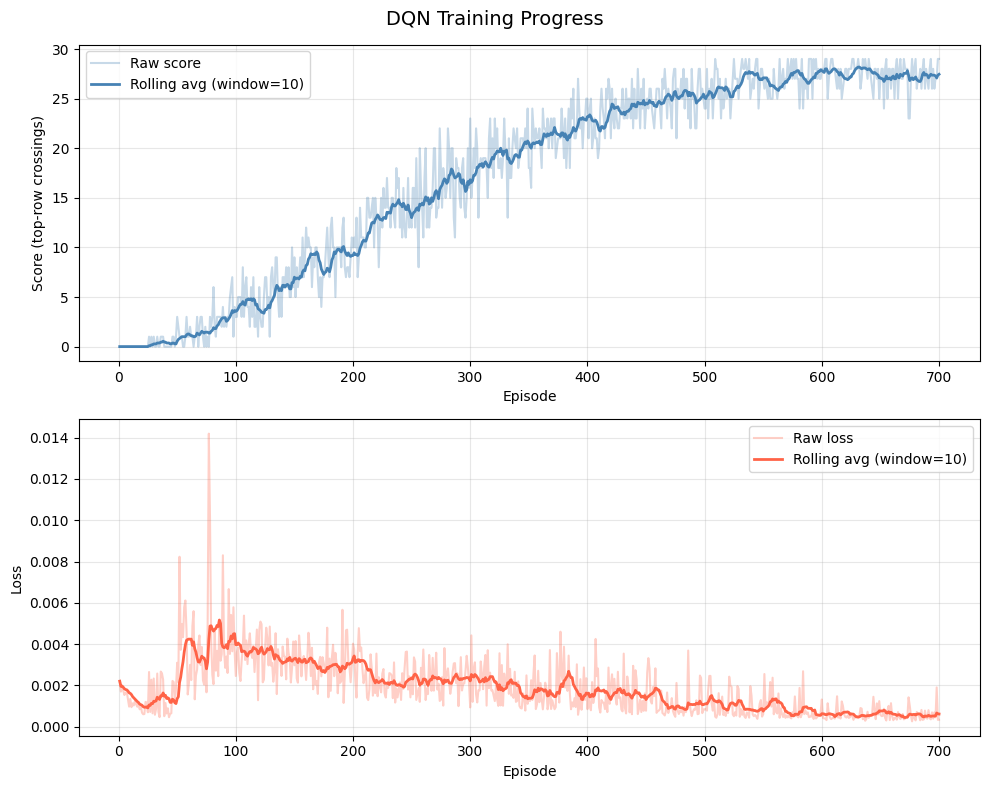

In [ ]:
import matplotlib.pyplot as plt
plot_training(scores, losses)

###Train Diff=1

In [ ]:
def train(n_episodes=650, gamma=0.90, lr=1e-4,
          epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995):

    env = SpaceRaceEnv(obs_mode="rgb", difficulty=1)
    model = DQN(n_actions=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epsilon = epsilon_start
    episode_scores = []
    episode_losses = []
    start_time = time.time()

    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_loss = 0
        steps = 0

        while not done:
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                    action = model(obs_t).argmax(dim=1).item()

            next_obs, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated

            batch = (obs, action, reward, next_obs, done)
            loss = compute_loss(model, batch, gamma)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            steps += 1
            obs, info = next_obs, next_info

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_scores.append(info['score'])
        episode_losses.append(total_loss / steps)

        if (episode + 1) % 10 == 0:
            print(f"Episode {episode+1} | Score: {np.mean(episode_scores[-10:]):.2f} "
                  f"| Loss: {np.mean(episode_losses[-10:]):.4f} "
                  f"| Epsilon: {epsilon:.3f}")
        if (episode + 1) % 200 == 0:
            torch.save(model.state_dict(), f"model_ep{episode+1}.pt")
            elapsed = time.time() - start_time
            hours = int(elapsed // 3600)
            minutes = int((elapsed % 3600) // 60)
            seconds = int(elapsed % 60)
            print(f"Checkpoint saved at episode {episode+1} | Time elapsed: {hours:02d}:{minutes:02d}:{seconds:02d}")


    return model, episode_scores, episode_losses

model, scores, losses = train()

torch.save(model.state_dict(), "model.pt")
print("model.pt saved")

Episode 10 | Score: 0.10 | Loss: 0.0012 | Epsilon: 0.951
Episode 20 | Score: 0.40 | Loss: 0.0016 | Epsilon: 0.905
Episode 30 | Score: 0.20 | Loss: 0.0010 | Epsilon: 0.860
Episode 40 | Score: 0.50 | Loss: 0.0013 | Epsilon: 0.818
Episode 50 | Score: 1.70 | Loss: 0.0038 | Epsilon: 0.778
Episode 60 | Score: 1.80 | Loss: 0.0041 | Epsilon: 0.740
Episode 70 | Score: 2.90 | Loss: 0.0032 | Epsilon: 0.704
Episode 80 | Score: 3.90 | Loss: 0.0038 | Epsilon: 0.670
Episode 90 | Score: 5.60 | Loss: 0.0027 | Epsilon: 0.637
Episode 100 | Score: 7.00 | Loss: 0.0028 | Epsilon: 0.606
Episode 110 | Score: 6.50 | Loss: 0.0028 | Epsilon: 0.576
Episode 120 | Score: 6.80 | Loss: 0.0030 | Epsilon: 0.548
Episode 130 | Score: 8.90 | Loss: 0.0024 | Epsilon: 0.521
Episode 140 | Score: 9.20 | Loss: 0.0021 | Epsilon: 0.496
Episode 150 | Score: 10.10 | Loss: 0.0032 | Epsilon: 0.471
Episode 160 | Score: 10.70 | Loss: 0.0022 | Epsilon: 0.448
Episode 170 | Score: 12.40 | Loss: 0.0025 | Epsilon: 0.427
Episode 180 | Score:

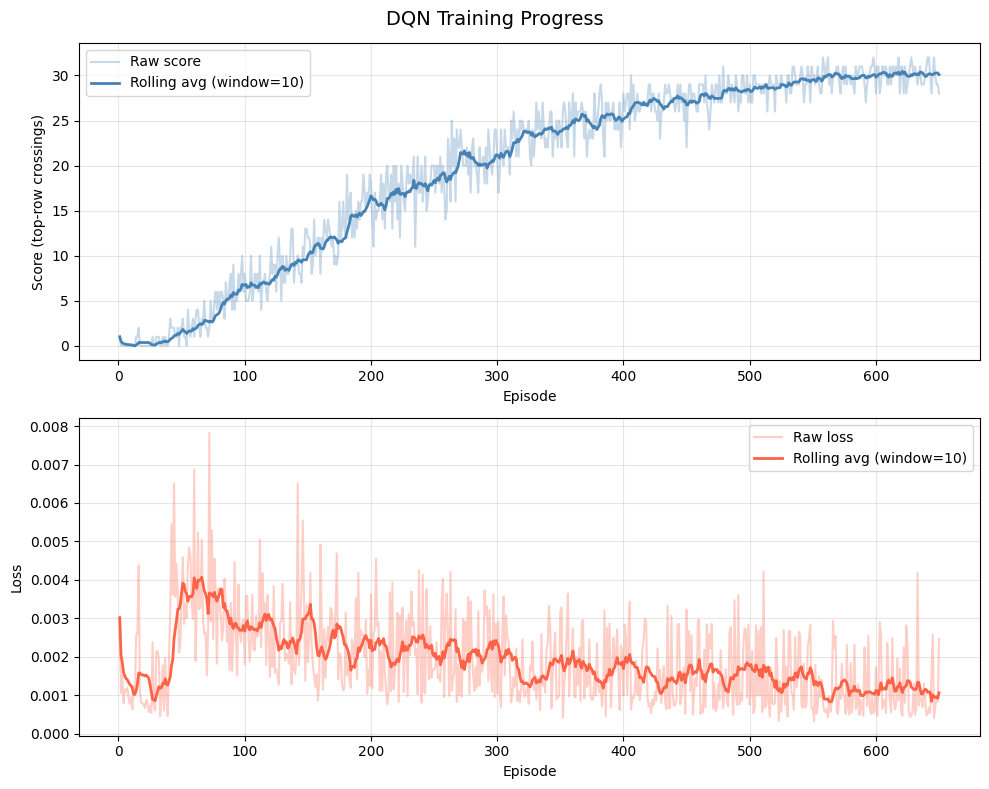

In [ ]:
import matplotlib.pyplot as plt
plot_training(scores, losses)

###Pretrain fine-tuned train

In [ ]:
def train_curriculum_mixed(pretrained_model_path="model.pt",
                           n_episodes=500,
                           gamma=0.90,
                           lr=1e-5,
                           epsilon_start=0.3,
                           epsilon_end=0.05,
                           epsilon_decay=0.995):

    model = DQN(n_actions=2).to(device)
    model.load_state_dict(torch.load(pretrained_model_path, map_location=device))
    print(f"Loaded weights from {pretrained_model_path}")

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epsilon = epsilon_start
    episode_scores_d0 = []
    episode_scores_d1 = []
    episode_losses = []
    start_time = time.time()

    for episode in range(n_episodes):
        # Alternate difficulties
        difficulty = 0 if episode % 2 == 0 else 1
        env = SpaceRaceEnv(obs_mode="rgb", difficulty=difficulty)

        obs, info = env.reset()
        done = False
        total_loss = 0
        steps = 0

        while not done:
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                    action = model(obs_t).argmax(dim=1).item()

            next_obs, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated

            batch = (obs, action, reward, next_obs, done)
            loss = compute_loss(model, batch, gamma)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            steps += 1
            obs, info = next_obs, next_info

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_losses.append(total_loss / steps)

        # Track scores separately per difficulty
        if difficulty == 0:
            episode_scores_d0.append(info['score'])
        else:
            episode_scores_d1.append(info['score'])

        if (episode + 1) % 10 == 0:
            mean_d0 = np.mean(episode_scores_d0[-5:]) if episode_scores_d0 else 0
            mean_d1 = np.mean(episode_scores_d1[-5:]) if episode_scores_d1 else 0
            print(f"Episode {episode+1} | D0: {mean_d0:.2f} | D1: {mean_d1:.2f} "
                  f"| Loss: {np.mean(episode_losses[-10:]):.4f} "
                  f"| Epsilon: {epsilon:.3f}")

        if (episode + 1) % 100 == 0:
            torch.save(model.state_dict(), f"model_mixed2_ep{episode+1}.pt")
            elapsed = time.time() - start_time
            hours = int(elapsed // 3600)
            minutes = int((elapsed % 3600) // 60)
            seconds = int(elapsed % 60)
            print(f"Checkpoint saved | Time elapsed: {hours:02d}:{minutes:02d}:{seconds:02d}")

    return model, episode_scores_d0, episode_scores_d1, episode_losses

In [ ]:
model_m, scores_d0, scores_d1, losses_m = train_curriculum_mixed(
    pretrained_model_path="model_0.pt",
    n_episodes=500
)

torch.save(model_m.state_dict(), "model_mixed.pt")
print("model_mixed.pt saved")

Loaded weights from model_0.pt
Episode 10 | D0: 15.60 | D1: 14.00 | Loss: 0.0064 | Epsilon: 0.285
Episode 20 | D0: 16.60 | D1: 15.20 | Loss: 0.0054 | Epsilon: 0.271
Episode 30 | D0: 15.80 | D1: 16.80 | Loss: 0.0037 | Epsilon: 0.258
Episode 40 | D0: 13.80 | D1: 13.60 | Loss: 0.0047 | Epsilon: 0.245
Episode 50 | D0: 15.40 | D1: 16.00 | Loss: 0.0046 | Epsilon: 0.233
Episode 60 | D0: 19.20 | D1: 17.20 | Loss: 0.0041 | Epsilon: 0.222
Episode 70 | D0: 18.40 | D1: 18.40 | Loss: 0.0048 | Epsilon: 0.211
Episode 80 | D0: 18.00 | D1: 17.60 | Loss: 0.0039 | Epsilon: 0.201
Episode 90 | D0: 19.40 | D1: 19.00 | Loss: 0.0032 | Epsilon: 0.191
Episode 100 | D0: 19.20 | D1: 19.00 | Loss: 0.0041 | Epsilon: 0.182
Checkpoint saved | Time elapsed: 00:04:51
Episode 110 | D0: 23.00 | D1: 19.20 | Loss: 0.0045 | Epsilon: 0.173
Episode 120 | D0: 18.60 | D1: 20.20 | Loss: 0.0037 | Epsilon: 0.164
Episode 130 | D0: 21.40 | D1: 21.80 | Loss: 0.0035 | Epsilon: 0.156
Episode 140 | D0: 22.00 | D1: 17.80 | Loss: 0.0040 |

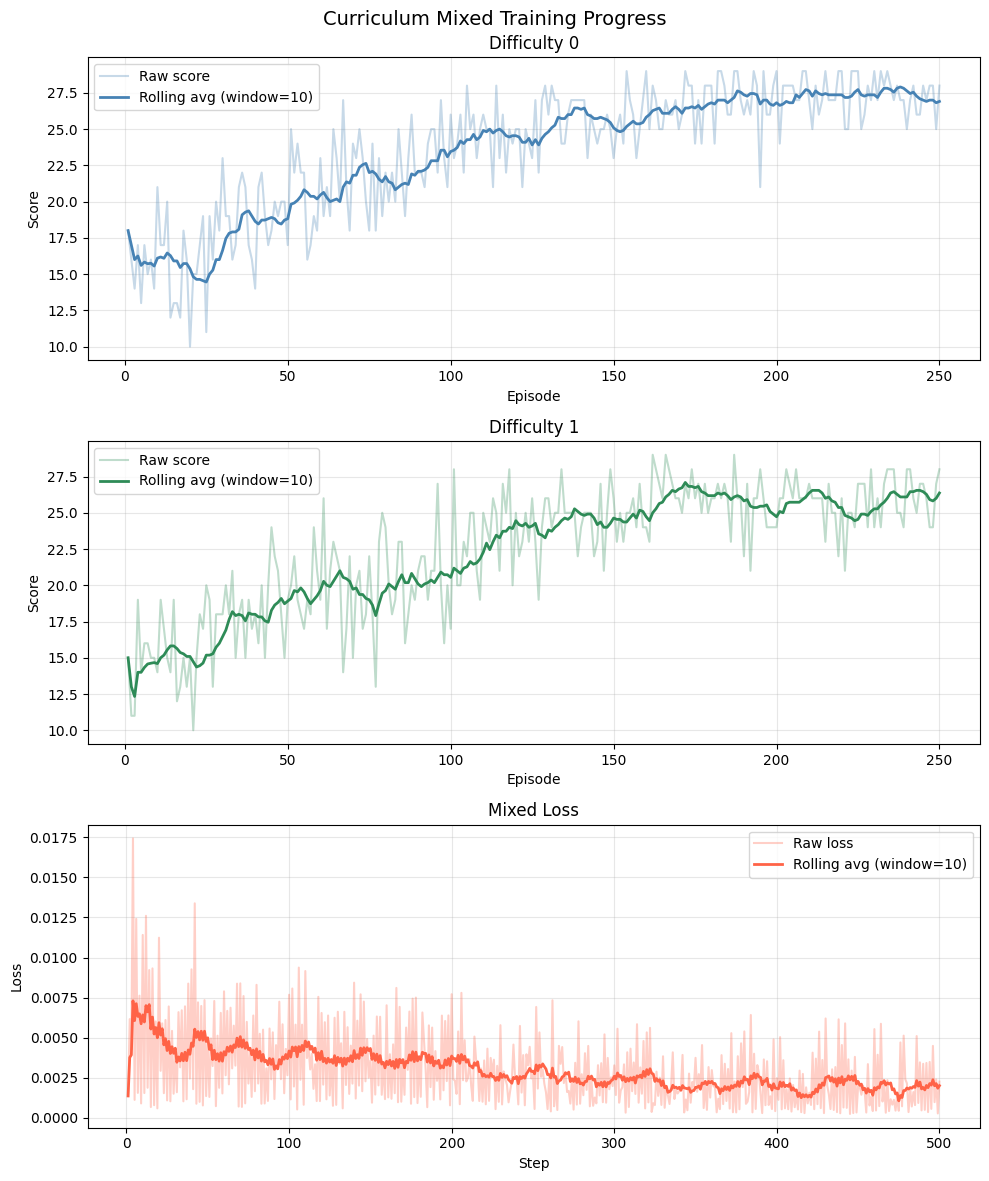

In [ ]:
import matplotlib.pyplot as plt

def plot_curriculum_training(scores_d0, scores_d1, losses_m, window=10):
    def rolling_avg(data, window):
        return [np.mean(data[max(0, i - window):i + 1]) for i in range(len(data))]

    ep0 = range(1, len(scores_d0) + 1)
    ep1 = range(1, len(scores_d1) + 1)
    ep_loss = range(1, len(losses_m) + 1)

    smooth_d0 = rolling_avg(scores_d0, window)
    smooth_d1 = rolling_avg(scores_d1, window)
    smooth_loss = rolling_avg(losses_m, window)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))
    fig.suptitle("Curriculum Mixed Training Progress", fontsize=14)

    ax1.plot(ep0, scores_d0, alpha=0.3, color="steelblue", label="Raw score")
    ax1.plot(ep0, smooth_d0, color="steelblue", linewidth=2, label=f"Rolling avg (window={window})")
    ax1.set_ylabel("Score")
    ax1.set_xlabel("Episode")
    ax1.set_title("Difficulty 0")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(ep1, scores_d1, alpha=0.3, color="seagreen", label="Raw score")
    ax2.plot(ep1, smooth_d1, color="seagreen", linewidth=2, label=f"Rolling avg (window={window})")
    ax2.set_ylabel("Score")
    ax2.set_xlabel("Episode")
    ax2.set_title("Difficulty 1")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3.plot(ep_loss, losses_m, alpha=0.3, color="tomato", label="Raw loss")
    ax3.plot(ep_loss, smooth_loss, color="tomato", linewidth=2, label=f"Rolling avg (window={window})")
    ax3.set_ylabel("Loss")
    ax3.set_xlabel("Step")
    ax3.set_title("Mixed Loss")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_curriculum_training(scores_d0, scores_d1, losses_m)

##Agent.py

In [ ]:
agent_code = '''
from __future__ import annotations
import numpy as np
import torch
import torch.nn as nn
import os

class DQN(nn.Module):
    def __init__(self, n_actions=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 13 * 9, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = x / 255.0
        x = self.conv(x)
        x = x.flatten(start_dim=1)
        return self.fc(x)

class Agent:
    def __init__(self) -> None:
        self.model = DQN(n_actions=2)
        model_path = os.path.join(os.path.dirname(__file__), "model_warmstart_1.pt")
        self.model.load_state_dict(torch.load(model_path, map_location="cpu"))
        self.model.eval()

    def select_action(self, obs: np.ndarray) -> int:
        with torch.no_grad():
            obs_t = torch.FloatTensor(obs).unsqueeze(0)
            q_values = self.model(obs_t)
            return int(q_values.argmax(dim=1).item())

'''

with open("agent.py", "w") as f:
    f.write(agent_code)
print("agent.py written")


agent.py written


##Test Like CodaBench

In [ ]:
!python local_eval.py --difficulty 0

In [ ]:
!zip submission.zip agent.py model.pt

  adding: agent.py (deflated 58%)
  adding: model_ep600.pt (deflated 7%)


In [ ]:
!python local_eval.py --difficulty 1

In [ ]:
!zip submission_diff_0_1.zip agent.py model_mixed.pt

  adding: agent.py (deflated 58%)
  adding: model_mixed.pt (deflated 7%)


Training results:
Training on difficulty 0 showed consistent score growth from 3.70 at episode 100 to 27.50 at episode 700, with loss steadily decreasing from 0.0040 to 0.0006. This falling loss alongside rising score is a good sign,  the Q-value targets are stabilising as the policy improves and epsilon decays.
Training on difficulty 1 from scratch converged faster, reaching 30.00 by episode 650, likely because faster debris creates more frequent collision events that provide better reward signal.

Curriculum learning:
Training on a single difficulty fails to generalise, the model trained on D0 only scored 24 on D1, and the model trained on D1 only collapsed to 7 on D0 (catastrophic forgetting).

A mixed curriculum was applied: starting from the D0 weights and alternating 50/50 between D0 and D1 episodes with a lower learning rate (1e-5) and lower starting epsilon (0.3). This preserved D0 knowledge while adapting to D1, achieving 29 on both simultaneously.

##Results until now
| Training Strategy                  | D0 | D1 |
|-----------------------------------|----|----|
| Trained on D0 only                | 29 | 24 |
| Trained on D1 only                |  7 | 32 |
| Curriculum D0 weigths loaded → D1                  | 21 | 31 |
| Mixed curriculum D0 weigths loaded → D1: episodes (50% in each diff) | 29 | 29 |

## Task 1.4

##Heuristic Diff=0

In [ ]:
def extract_info_from_obs(semantic_obs):
    ship_channel = semantic_obs[:, :, 0]
    debris_channel = semantic_obs[:, :, 1]

    ship_pos = np.where(ship_channel == 1.0)
    if len(ship_pos[0]) == 0:
        return None, None, False

    ship_row, ship_col = ship_pos[0][0], ship_pos[1][0]

    if ship_row == 0:
        return ship_row, ship_col, False

    row_above = ship_row - 1
    cols_to_check = [c for c in [ship_col - 1, ship_col, ship_col + 1]
                     if 0 <= c < debris_channel.shape[1]]

    debris_threat = any(debris_channel[row_above, c] > 0 for c in cols_to_check)
    return ship_row, ship_col, debris_threat


def heuristic_policy(info):
    semantic_obs = info["semantic_obs"]
    _, _, debris_threat = extract_info_from_obs(semantic_obs)
    return 1 if debris_threat else 0

In [ ]:
def collect_heuristic_data(n_episodes=50, difficulty=0):
    env = SpaceRaceEnv(obs_mode="rgb", difficulty=difficulty, include_semantic_info=True)  # semantic info enabled
    experiences = []
    scores = []

    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False

        while not done:
            action = heuristic_policy(info)  # uses info["semantic_obs"] internally
            next_obs, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated

            # Store RGB transitions — what the CNN will learn from
            experiences.append((obs, action, reward, next_obs, float(done)))
            obs, info = next_obs, next_info

        scores.append(info['score'])

    print(f"Collected {len(experiences)} transitions over {n_episodes} episodes")
    print(f"Heuristic Mean Score: {np.mean(scores):.2f} ± {np.std(scores):.2f}")
    return experiences, scores

In [ ]:
def pretrain_on_heuristic(experiences, n_epochs=5, gamma=0.90, lr=1e-4):
    model = DQN(n_actions=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_losses = []

    for epoch in range(n_epochs):
        # Shuffle experiences each epoch
        np.random.shuffle(experiences)
        total_loss = 0

        for obs, action, reward, next_obs, done in experiences:
            batch = (obs, action, reward, next_obs, done)
            loss = compute_loss(model, batch, gamma)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(experiences)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f}")

    return model, epoch_losses

In [ ]:
def train_from_warmstart(pretrained_model, n_episodes=500, gamma=0.90,
                         lr=1e-4, epsilon_start=0.3,
                         epsilon_end=0.05, epsilon_decay=0.995):

    env = SpaceRaceEnv(obs_mode="rgb", difficulty=0)

    model = pretrained_model
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epsilon = epsilon_start
    episode_scores = []
    episode_losses = []
    start_time = time.time()

    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_loss = 0
        steps = 0

        while not done:
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                    action = model(obs_t).argmax(dim=1).item()

            next_obs, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated

            batch = (obs, action, reward, next_obs, done)
            loss = compute_loss(model, batch, gamma)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            steps += 1
            obs, info = next_obs, next_info

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_scores.append(info['score'])
        episode_losses.append(total_loss / steps)

        if (episode + 1) % 10 == 0:
            print(f"Episode {episode+1} | Score: {np.mean(episode_scores[-10:]):.2f} "
                  f"| Loss: {np.mean(episode_losses[-10:]):.4f} "
                  f"| Epsilon: {epsilon:.3f}")

        if (episode + 1) % 100 == 0:
            torch.save(model.state_dict(), f"model_warmstart_ep{episode+1}.pt")
            elapsed = time.time() - start_time
            hours = int(elapsed // 3600)
            minutes = int((elapsed % 3600) // 60)
            seconds = int(elapsed % 60)
            print(f"Checkpoint saved | Time elapsed: {hours:02d}:{minutes:02d}:{seconds:02d}")

    return model, episode_scores, episode_losses

In [ ]:
# 1. Collect heuristic data
experiences, heuristic_scores = collect_heuristic_data(n_episodes=50)

# 2. Pre-train on heuristic data
model_ws, pretrain_losses = pretrain_on_heuristic(experiences, n_epochs=5)

# 3. Continue training with RL
model_ws, scores_ws, losses_ws = train_from_warmstart(model_ws, n_episodes=500)

# 4. Save
torch.save(model_ws.state_dict(), "model_warmstart.pt")
print("model_warmstart.pt saved")

Collected 30000 transitions over 50 episodes
Heuristic Mean Score: 22.00 ± 0.00
Epoch 1/5 | Loss: 0.0019
Epoch 2/5 | Loss: 0.0003
Epoch 3/5 | Loss: 0.0002
Epoch 4/5 | Loss: 0.0002
Epoch 5/5 | Loss: 0.0001
Episode 10 | Score: 7.60 | Loss: 0.0096 | Epsilon: 0.285
Episode 20 | Score: 10.10 | Loss: 0.0095 | Epsilon: 0.271
Episode 30 | Score: 14.50 | Loss: 0.0072 | Epsilon: 0.258
Episode 40 | Score: 13.60 | Loss: 0.0055 | Epsilon: 0.245
Episode 50 | Score: 16.00 | Loss: 0.0043 | Epsilon: 0.233
Episode 60 | Score: 17.90 | Loss: 0.0035 | Epsilon: 0.222
Episode 70 | Score: 16.90 | Loss: 0.0037 | Epsilon: 0.211
Episode 80 | Score: 19.20 | Loss: 0.0033 | Epsilon: 0.201
Episode 90 | Score: 19.80 | Loss: 0.0022 | Epsilon: 0.191
Episode 100 | Score: 18.40 | Loss: 0.0027 | Epsilon: 0.182
Checkpoint saved | Time elapsed: 00:04:32
Episode 110 | Score: 21.70 | Loss: 0.0023 | Epsilon: 0.173
Episode 120 | Score: 20.10 | Loss: 0.0027 | Epsilon: 0.164
Episode 130 | Score: 21.60 | Loss: 0.0022 | Epsilon: 0.

In [ ]:
!python local_eval.py --difficulty 0

  Episode  1/10  →  score = 29
  Episode  2/10  →  score = 29
  Episode  3/10  →  score = 29
  Episode  4/10  →  score = 29
  Episode  5/10  →  score = 29
  Episode  6/10  →  score = 29
  Episode  7/10  →  score = 29
  Episode  8/10  →  score = 29
  Episode  9/10  →  score = 29
  Episode 10/10  →  score = 29

--- Results (difficulty=0) ---
  Mean : 29.00
  Std  : 0.00
  Min  : 29
  Max  : 29



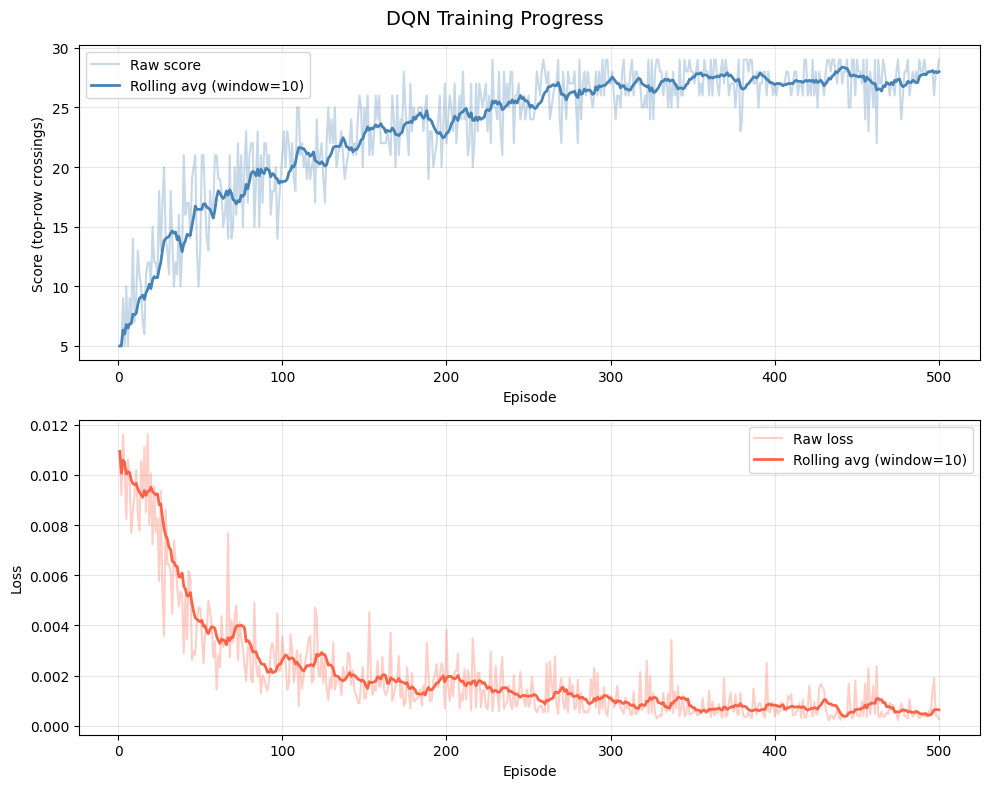

In [ ]:
import matplotlib.pyplot as plt
plot_training(scores_ws, losses_ws)

##Heuristic Diff=1

In [ ]:
def extract_info_from_obs(semantic_obs):
    ship_channel = semantic_obs[:, :, 0]
    debris_channel = semantic_obs[:, :, 1]

    ship_pos = np.where(ship_channel == 1.0)
    if len(ship_pos[0]) == 0:
        return None, None, False

    ship_row, ship_col = ship_pos[0][0], ship_pos[1][0]

    if ship_row == 0:
        return ship_row, ship_col, False

    row_above = ship_row - 1
    cols_to_check = [c for c in [ship_col - 1, ship_col, ship_col + 1]
                     if 0 <= c < debris_channel.shape[1]]

    debris_threat = any(debris_channel[row_above, c] > 0 for c in cols_to_check)
    return ship_row, ship_col, debris_threat


def heuristic_policy(info):
    semantic_obs = info["semantic_obs"]
    _, _, debris_threat = extract_info_from_obs(semantic_obs)
    return 1 if debris_threat else 0

In [ ]:
def collect_heuristic_data(n_episodes=50, difficulty=1):
    env = SpaceRaceEnv(obs_mode="rgb", difficulty=difficulty, include_semantic_info=True)  # semantic info enabled
    experiences = []
    scores = []

    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False

        while not done:
            action = heuristic_policy(info)  # uses info["semantic_obs"] internally
            next_obs, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated

            # Store RGB transitions — what the CNN will learn from
            experiences.append((obs, action, reward, next_obs, float(done)))
            obs, info = next_obs, next_info

        scores.append(info['score'])

    print(f"Collected {len(experiences)} transitions over {n_episodes} episodes")
    print(f"Heuristic Mean Score: {np.mean(scores):.2f} ± {np.std(scores):.2f}")
    return experiences, scores

In [ ]:
def pretrain_on_heuristic(experiences, n_epochs=5, gamma=0.90, lr=1e-4):
    model = DQN(n_actions=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_losses = []

    for epoch in range(n_epochs):
        # Shuffle experiences each epoch
        np.random.shuffle(experiences)
        total_loss = 0

        for obs, action, reward, next_obs, done in experiences:
            batch = (obs, action, reward, next_obs, done)
            loss = compute_loss(model, batch, gamma)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(experiences)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f}")

    return model, epoch_losses

In [ ]:
def train_from_warmstart(pretrained_model, n_episodes=500, gamma=0.90,
                         lr=1e-4, epsilon_start=0.3,
                         epsilon_end=0.05, epsilon_decay=0.995):

    env = SpaceRaceEnv(obs_mode="rgb", difficulty=1)

    model = pretrained_model
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epsilon = epsilon_start
    episode_scores = []
    episode_losses = []
    start_time = time.time()

    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_loss = 0
        steps = 0

        while not done:
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                    action = model(obs_t).argmax(dim=1).item()

            next_obs, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated

            batch = (obs, action, reward, next_obs, done)
            loss = compute_loss(model, batch, gamma)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            steps += 1
            obs, info = next_obs, next_info

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_scores.append(info['score'])
        episode_losses.append(total_loss / steps)

        if (episode + 1) % 10 == 0:
            print(f"Episode {episode+1} | Score: {np.mean(episode_scores[-10:]):.2f} "
                  f"| Loss: {np.mean(episode_losses[-10:]):.4f} "
                  f"| Epsilon: {epsilon:.3f}")

        if (episode + 1) % 100 == 0:
            torch.save(model.state_dict(), f"model_warmstart_ep{episode+1}.pt")
            elapsed = time.time() - start_time
            hours = int(elapsed // 3600)
            minutes = int((elapsed % 3600) // 60)
            seconds = int(elapsed % 60)
            print(f"Checkpoint saved | Time elapsed: {hours:02d}:{minutes:02d}:{seconds:02d}")

    return model, episode_scores, episode_losses

In [ ]:
# 1. Collect heuristic data
experiences, heuristic_scores = collect_heuristic_data(n_episodes=50)

# 2. Pre-train on heuristic data
model_ws, pretrain_losses = pretrain_on_heuristic(experiences, n_epochs=5)

# 3. Continue training with RL
model_ws, scores_ws, losses_ws = train_from_warmstart(model_ws, n_episodes=300)

# 4. Save
torch.save(model_ws.state_dict(), "model_warmstart_1.pt")
print("model_warmstart_1.pt saved")

Collected 30000 transitions over 50 episodes
Heuristic Mean Score: 21.00 ± 0.00
Epoch 1/5 | Loss: 0.0029
Epoch 2/5 | Loss: 0.0004
Epoch 3/5 | Loss: 0.0003
Epoch 4/5 | Loss: 0.0002
Epoch 5/5 | Loss: 0.0002
Episode 10 | Score: 11.10 | Loss: 0.0127 | Epsilon: 0.285
Episode 20 | Score: 13.40 | Loss: 0.0095 | Epsilon: 0.271
Episode 30 | Score: 19.60 | Loss: 0.0044 | Epsilon: 0.258
Episode 40 | Score: 19.30 | Loss: 0.0039 | Epsilon: 0.245
Episode 50 | Score: 21.10 | Loss: 0.0031 | Epsilon: 0.233
Episode 60 | Score: 19.60 | Loss: 0.0030 | Epsilon: 0.222
Episode 70 | Score: 21.30 | Loss: 0.0027 | Epsilon: 0.211
Episode 80 | Score: 21.90 | Loss: 0.0031 | Epsilon: 0.201
Episode 90 | Score: 22.30 | Loss: 0.0029 | Epsilon: 0.191
Episode 100 | Score: 22.30 | Loss: 0.0027 | Epsilon: 0.182
Checkpoint saved | Time elapsed: 00:04:33
Episode 110 | Score: 23.50 | Loss: 0.0023 | Epsilon: 0.173
Episode 120 | Score: 22.60 | Loss: 0.0028 | Epsilon: 0.164
Episode 130 | Score: 23.90 | Loss: 0.0025 | Epsilon: 0

In [ ]:
!python local_eval.py --difficulty 1

  Episode  1/10  →  score = 32
  Episode  2/10  →  score = 32
  Episode  3/10  →  score = 32
  Episode  4/10  →  score = 32
  Episode  5/10  →  score = 32
  Episode  6/10  →  score = 32
  Episode  7/10  →  score = 32
  Episode  8/10  →  score = 32
  Episode  9/10  →  score = 32
  Episode 10/10  →  score = 32

--- Results (difficulty=1) ---
  Mean : 32.00
  Std  : 0.00
  Min  : 32
  Max  : 32



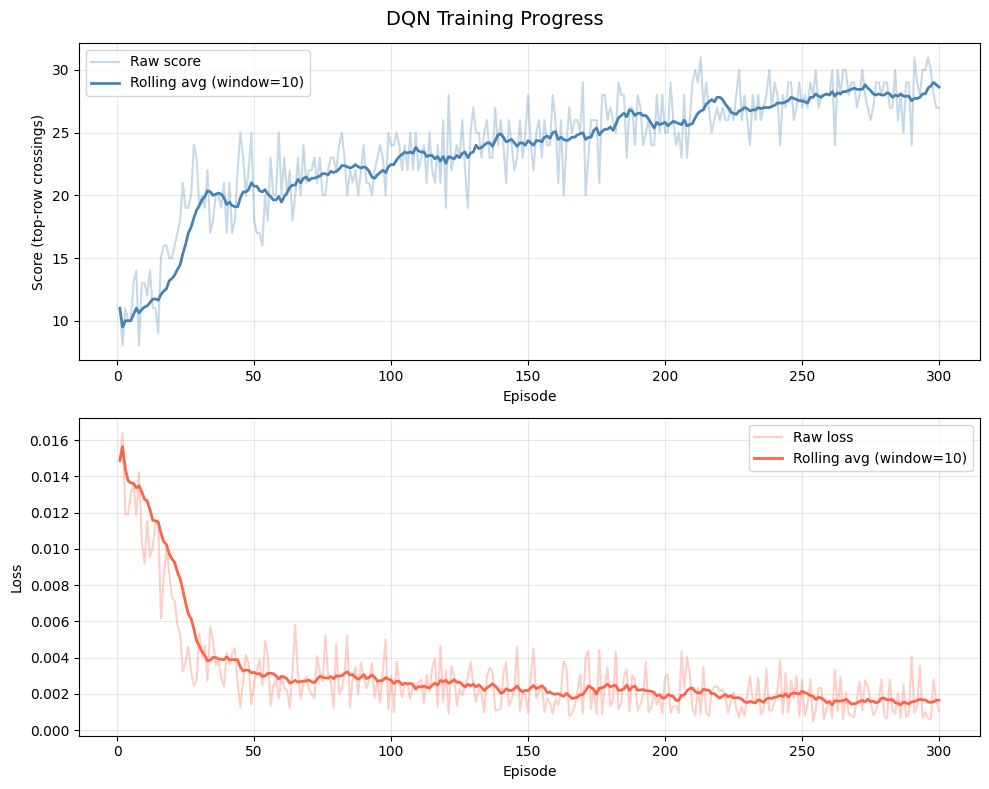

In [ ]:
import matplotlib.pyplot as plt
plot_training(scores_ws, losses_ws)

The heuristic uses the semantic observation available during training, which provides exact ship and debris positions on the 18 × 13 grid.

At each step it checks the three cells in the row directly above the ship, the cell directly above and its immediate left and right neighbours. If any contain debris the agent moves down, otherwise it moves up.
The three-cell window accounts for the horizontal movement of debris: even if the cell directly above is clear, debris one cell to the left or right may slide into that position before the next step.

This simple rule achieved a mean score of 22 on D0 and 21 on D1 without any learning.

Warm-start results:
The heuristic data was used to pre-train the CNN before switching to RL, starting epsilon at 0.3 rather than 1.0 since the policy was already reasonable. The impact on sample efficiency was significant:

| Training setup  | Episodes to reach score ~27 | Final score |
| --------------- | --------------------------- | ----------- |
| D0 from scratch | ~600                        | 29          |
| D0 warm-start   | ~300                        | 29          |
| D1 from scratch | ~600                        | 32          |
| D1 warm-start   | ~270                        | 32          |


The warm-start reached the same final performance in roughly half the episodes. Notably the DQN surpassed its teacher, the heuristic scored 22/21 but the final policy reached 29/32, demonstrating that RL fine-tuning discovered behaviours the heuristic could not encode, despite learning only from RGB pixels without access to semantic information.

# **Task 2 -  Enhanced DQN with Experience Replay and Target Network**

In [ ]:
import collections
import random
import numpy as np
import copy
import torch
import torch.nn as nn
import time

## **Task 2.1 -  Experience Replay Buffer Implementation**

In Task 1, the agent learned immediately from each transition - via the current state, it took an action, received the reward, and then updated the network. The problem is that consecutive states are very similar to each other (the current frame and the one from 1 second ago are almost identical), and this confuses the network.

The Replay Buffer solves this: it stores past experiences and learns from random samples from the past, instead of always from the present moment.

### **Buffer Structure, Transition Storage and Memory Management**

In [ ]:
#Implementation of a Replay Buffer
class ReplayBuffer:

    def __init__(self, capacity=10_000): #Max of experiences that are saved
        self.buffer = collections.deque(maxlen=capacity) #FIFO

    #Saving a transiction, with a
    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    #Random sampling of experiences
    def sample(self, batch_size):

        #We guarantee that we don't request more samples than are available.
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))

        #Unpack the 5 components of each transition.
        states, actions, rewards, next_states, dones = zip(*batch)

         #Convert to appropriate tensor format
        return (
            np.array(states, dtype=np.uint8), #(B, 54, 39, 3)
            np.array(actions, dtype=np.int64),  #(B,)
            np.array(rewards, dtype=np.float32),  #(B,)
            np.array(next_states, dtype=np.uint8),  #(B, 54, 39, 3)
            np.array(dones, dtype=np.float32),   #(B,)  1.0 = end
        )

    def __len__(self):
        return len(self.buffer)

    def is_ready(self, batch_size):
        return len(self.buffer) >= batch_size

### **Prioritized Experience Replay**

PER solves a buffer problem: all transitions have the same probability of being sampled, but some are much more informative than others. Transitions with high TD-error are those where the network was most wrong, they are the most useful for learning.

Two key concepts:

- α (alpha): controls how much is prioritized. α=0 → uniform; α=1 → fully proportional to the error.

- β (beta): corrects the bias introduced by non-uniform sampling (importance sampling weights). It starts low and increases to 1 during training.

In [ ]:
#Instead of sampling uniformly, transitions with higher |TD-error| are more likely to be chosen.
#This speeds up learning because the agent focuses on the most "surprising" experiences.
class PrioritizedReplayBuffer:

    #Parameters:
    #Capacity - max transitions (10000)
    #Alpha - degree of priorization
    #Beta - importance sampling fator
    #Beta increment - ao much beta increases
    #Epsilon - small constant to avoid 0 priority

    def __init__(self, capacity=10_000, alpha=0.6, beta=0.4,
                 beta_increment=0.001, epsilon=1e-5):
        self.capacity = capacity
        self.alpha = alpha
        self.beta = beta
        self.beta_increment = beta_increment
        self.epsilon = epsilon

        self.buffer = [] #List with transitions
        self.priorities  = np.zeros(capacity, dtype=np.float32)  #Priority
        self.pos = 0 #Position
        self.size = 0 #Number of transictions

    #New transitions have max priority, make sure that each new experience is sampled at least 1 time
    def add(self, state, action, reward, next_state, done):

        max_priority = self.priorities[:self.size].max() if self.size > 0 else 1.0

        if self.size < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
            self.size += 1
        else:
            #Overwrite the oldest position (circular)
            self.buffer[self.pos] = (state, action, reward, next_state, done)

        self.priorities[self.pos] = max_priority
        self.pos = (self.pos + 1) % self.capacity

    #Sampling proportional to priority^alpha
    #Returns: usual batch + indexes (for later update) + IS weights.
    def sample(self, batch_size):

        #Priorities of existing transitions raised to alpha.
        priorities = self.priorities[:self.size] ** self.alpha
        probs      = priorities / priorities.sum()   # normalizar → distribuição

        #Sample indices according to this distribution.
        indices = np.random.choice(self.size, size=batch_size,
                                   replace=False, p=probs)

        #Importance-sampling weights correct for the bias of non-uniform sampling.
        weights = (self.size * probs[indices]) ** (-self.beta)
        weights /= weights.max()   # normalizar para estabilidade

        #Advance beta towards 1 (annealing)
        self.beta = min(1.0, self.beta + self.beta_increment)

        #Collect transitions
        batch = [self.buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states, dtype=np.uint8),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.uint8),
            np.array(dones, dtype=np.float32),
            indices,
            weights.astype(np.float32),
        )

    #After each network update, we recalculate the actual TD-error and update the priorities of those transitions.
    def update_priorities(self, indices, td_errors):

        for idx, error in zip(indices, td_errors):
            #Epsilon avoids priority 0 (transition would never be sampled)
            self.priorities[idx] = abs(error) + self.epsilon

    def __len__(self):
        return self.size

    def is_ready(self, batch_size):
        return self.size >= batch_size

### **On-Policy and Off-Policy training and the size of the Replay Buffer**

In [ ]:
buffer_size_1 = ReplayBuffer(capacity=1)
buffer_size_100 = ReplayBuffer(capacity=100)
buffer_size_10000 = ReplayBuffer(capacity=10_000)

### **Batch Sampling**

In [ ]:
def compute_loss_batch(model, batch, gamma=0.9):
    """
    Versão vectorizada da loss — processa um batch inteiro de uma vez.

    Comparado com a Task 1 (1 transição de cada vez):
    - Muito mais eficiente na GPU (operações matriciais paralelas)
    - Gradientes mais estáveis (média de B erros em vez de 1)
    - Necessário para trabalhar com o replay buffer
    """
    states, actions, rewards, next_states, dones = batch

    # Converter para tensores e enviar para device
    # Estados: uint8 → float32, normalização dentro da rede (como na Task 1)
    states      = torch.FloatTensor(states).to(device)       # (B, 54, 39, 3)
    next_states = torch.FloatTensor(next_states).to(device)  # (B, 54, 39, 3)
    actions     = torch.LongTensor(actions).to(device)       # (B,)
    rewards     = torch.FloatTensor(rewards).to(device)      # (B,)
    dones       = torch.FloatTensor(dones).to(device)        # (B,)

    # Q(s, a) — apenas o valor da acção tomada
    q_values = model(states)                          # (B, 2)
    q_value  = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)  # (B,)

    # max Q(s', a') — sem gradiente (target não é treinado aqui, isso é Task 2.2)
    with torch.no_grad():
        next_q_values  = model(next_states)           # (B, 2)
        max_next_q     = next_q_values.max(dim=1)[0]  # (B,)

    # Bellman target com masking de episódios terminados
    target = rewards + gamma * max_next_q * (1.0 - dones)

    # MSE loss sobre o batch inteiro
    loss = ((target - q_value) ** 2).mean()
    return loss

## **Task 2.2 - Integration with DQN Training**

### **Loss Function - uses the target network for stable Bellman targets**

In [ ]:
#Computes the DQN loss for a full batch, using a separate frozen target network to generate stable Bellman targets
def compute_loss_dqn(primary_net, target_net, batch, gamma=0.99):

    #Parameters:
    #primary_net: the network being trained (gradients flow through this)
    #target_net: frozen copy of primary_net, updated every C steps
    #batch: tuple of (states, actions, rewards, next_states, dones) as returned by ReplayBuffer.sample()
    #gamma: discount factor

    # Convert numpy arrays to tensors and move to the correct device.
    # States are stored as uint8 in the buffer (memory-efficient),and normalised to [0, 1] inside the DQN's forward()
    states, actions, rewards, next_states, dones = batch

    states      = torch.FloatTensor(states).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    actions     = torch.LongTensor(actions).to(device)
    rewards     = torch.FloatTensor(rewards).to(device)
    dones       = torch.FloatTensor(dones).to(device)

    #Primary network: Q(s, a)
    # Forward pass through the primary network (gradients are tracked here)
    q_values = primary_net(states)                                   # (B, n_actions)
    q_value  = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)   # (B,)

    #Target network: max Q(s', a')
    with torch.no_grad():
        next_q_values = target_net(next_states)        # (B, n_actions)
        max_next_q    = next_q_values.max(dim=1)[0]    # (B,)  greedy max over actions

    #Bellman target
    target = rewards + gamma * max_next_q * (1.0 - dones)  # (B,)

    #MSE loss
    loss = nn.functional.mse_loss(q_value, target)
    return loss, q_value.detach(), target.detach()

### **Buffer population helpers**

In [ ]:
#Fills the replay buffer with RANDOM (epsilon=1) transitions
#The buffer must contain a minimum number of diverse experiences

def populate_buffer_random(buffer, env, n_steps=1000):
    obs, info = env.reset()
    collected = 0

    while collected < n_steps:
        action = env.action_space.sample()
        next_obs, reward, terminated, truncated, next_info = env.step(action)
        done = terminated or truncated

        buffer.add(obs, action, reward, next_obs, float(done))
        collected += 1

        if done:
            obs, info = env.reset()
        else:
            obs, info = next_obs, next_info

    print(f"[Buffer] Random warm-up complete: {len(buffer)} transitions stored.")

#Fills the replay buffer using the HEURISTIC policy from Task 1.4
#Random exploration collects many useless transitions
#The heuristic already knows to dodge, so its transitions contain more informative reward signal

def populate_buffer_heuristic(buffer, env_difficulty=0, n_episodes=30):

    #Heuristic needs semantic observations to decide actions
    env = SpaceRaceEnv(obs_mode="rgb", difficulty=env_difficulty, include_semantic_info=True)
    scores = []

    for ep in range(n_episodes):
        obs, info = env.reset()
        done = False

        while not done:
            #Heuristic selects action using semantic info (not available at test time)
            action = heuristic_policy(info)

            next_obs, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated

            #Store RGB transitions — only what the CNN will ever see
            buffer.add(obs, action, reward, next_obs, float(done))
            obs, info = next_obs, next_info

        scores.append(info['score'])

    print(f"[Buffer] Heuristic warm-up complete: {len(buffer)} transitions stored. "
          f"Mean heuristic score: {np.mean(scores):.1f} ± {np.std(scores):.1f}")

### **Full DQN training loop with replay buffer + target network**

In [ ]:
def train_dqn(
    difficulty=0,
    n_episodes=600,
    #Replay buffer
    buffer_capacity=10_000,
    batch_size=64,
    #Random warm-up before training starts
    warmup_random_steps=2_000,
    warmup_heuristic_ep=30,
    #Target network
    target_update_freq=500,
    #Optimisation
    gamma=0.99,
    lr=1e-4,
    #Exploration schedule
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.995,
    #Misc
    train_freq=1,
    use_per=False,
    pretrained_path= None,
):

    #Environment
    env = SpaceRaceEnv(obs_mode="rgb", difficulty=difficulty)

    #Newtoworks with  primary_net (trained every step) and (target_net)
    primary_net = DQN(n_actions=2).to(device)

    if pretrained_path is not None:
        primary_net.load_state_dict(torch.load(pretrained_path, map_location=device))
        print(f"[Init] Loaded primary network weights from '{pretrained_path}'")

    target_net = copy.deepcopy(primary_net).to(device)

    target_net.eval()
    for p in target_net.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(primary_net.parameters(), lr=lr)

    #Replay buffer
    if use_per:
        buffer = PrioritizedReplayBuffer(capacity=buffer_capacity)
        print("[Buffer] Using Prioritized Experience Replay (PER).")
    else:
        buffer = ReplayBuffer(capacity=buffer_capacity)
        print("[Buffer] Using uniform Replay Buffer.")

    #Buffer warm-start (fill the buffer with useful transitions BEFORE the first gradient)
    #Heuristic policy (high-quality, reward-rich transitions) and Random policy (ensures diversity and state coverage)
    print("\nPhase 1: Buffer warm-start (heuristic)")
    populate_buffer_heuristic(buffer, env_difficulty=difficulty,
                               n_episodes=warmup_heuristic_ep)

    print("\nPhase 2: Buffer warm-start (random)")
    populate_buffer_random(buffer, env, n_steps=warmup_random_steps)

    print(f"\n[Buffer] Total transitions before training: {len(buffer)}")
    print(f"[Buffer] Training will start once buffer has >= {batch_size} samples "
          f"(currently: {len(buffer) >= batch_size})\n")

    #Training loop
    epsilon        = epsilon_start
    episode_scores = []
    episode_losses = []
    total_steps    = 0
    start_time     = time.time()

    for episode in range(n_episodes):
        obs, info = env.reset()
        done        = False
        total_loss  = 0.0
        update_count = 0

        while not done:

            #Action selection, epsilon-greedy exploration
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    obs_t  = torch.FloatTensor(obs).unsqueeze(0).to(device)
                    action = primary_net(obs_t).argmax(dim=1).item()
                    del obs_t

            #Environment step
            next_obs, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated

            #Store transition in the replay buffer
            buffer.add(obs, action, reward, next_obs, float(done))

            obs   = next_obs
            info  = next_info
            total_steps += 1

            #Training a sample a random batch and update primary net
            if buffer.is_ready(batch_size) and (total_steps % train_freq == 0):

                if use_per:
                    states, actions_b, rewards_b, next_states, dones_b, \
                        indices, is_weights = buffer.sample(batch_size)

                    batch = (states, actions_b, rewards_b, next_states, dones_b)
                    loss, q_pred, q_tgt = compute_loss_dqn(primary_net, target_net, batch, gamma)

                    #Weight the loss by importance-sampling correction
                    is_weights_t = torch.FloatTensor(is_weights).to(device)
                    loss = (loss * is_weights_t).mean()

                    td_errors = (q_pred - q_tgt).abs().cpu().numpy()
                    buffer.update_priorities(indices, td_errors)

                    del is_weights_t, q_pred, q_tgt  # NOVO: liberta tensores

                else:
                    batch = buffer.sample(batch_size)
                    loss, _, _ = compute_loss_dqn(primary_net, target_net, batch, gamma)


                #Gradient step
                optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(primary_net.parameters(), max_norm=1.0)
                optimizer.step()

                total_loss   += loss.item()
                update_count += 1

                del loss

            #Target network hard update
            if total_steps % target_update_freq == 0:
                target_net.load_state_dict(primary_net.state_dict())
                #Target stays in eval mode with frozen gradients
                target_net.eval()
                for p in target_net.parameters():
                    p.requires_grad = False


        #Decay epsilon once per episode
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        episode_scores.append(info['score'])
        episode_losses.append(total_loss / update_count if update_count > 0 else 0.0)

        if (episode + 1) % 50 == 0:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        #Periodic logging
        if (episode + 1) % 10 == 0:
            print(f"Episode {episode+1:4d} | "
                  f"Score: {np.mean(episode_scores[-10:]):6.2f} | "
                  f"Loss: {np.mean(episode_losses[-10:]):.4f} | "
                  f"Epsilon: {epsilon:.3f} | "
                  f"Buffer: {len(buffer):6d} | "
                  f"Steps: {total_steps:7d}")

        #Periodic checkpoints
        if (episode + 1) % 200 == 0:
            ckpt = f"model_dqn_d{difficulty}_ep{episode+1}.pt"
            torch.save(primary_net.state_dict(), ckpt)
            elapsed = time.time() - start_time
            h, m, s = int(elapsed // 3600), int((elapsed % 3600) // 60), int(elapsed % 60)
            print(f"[Checkpoint] Saved '{ckpt}' | Elapsed: {h:02d}:{m:02d}:{s:02d}")

    return primary_net, episode_scores, episode_losses

### **Training with heuristic warm-start (Difficulty 0)**

In [ ]:
model_dqn_d0, scores_dqn_d0, losses_dqn_d0 = train_dqn(
    difficulty              = 0,
    n_episodes              = 500,
    buffer_capacity         = 10_000,
    batch_size              = 32,
    warmup_random_steps     = 500,
    warmup_heuristic_ep     = 5,
    target_update_freq      = 500,
    gamma                   = 0.99,
    lr                      = 1e-4,
    epsilon_start           = 0.5,
    epsilon_end             = 0.05,
    epsilon_decay           = 0.995,
    use_per                 = False,
)

torch.save(model_dqn_d0.state_dict(), "model_dqn_d0.pt")
print("model_dqn_d0.pt saved")

[Buffer] Using uniform Replay Buffer.

Phase 1: Buffer warm-start (heuristic)
[Buffer] Heuristic warm-up complete: 3000 transitions stored. Mean heuristic score: 22.0 ± 0.0

Phase 2: Buffer warm-start (random)
[Buffer] Random warm-up complete: 3500 transitions stored.

[Buffer] Total transitions before training: 3500
[Buffer] Training will start once buffer has >= 32 samples (currently: True)

Episode   10 | Score:   2.10 | Loss: 0.0041 | Epsilon: 0.476 | Buffer:   9500 | Steps:    6000
Episode   20 | Score:   6.00 | Loss: 0.0089 | Epsilon: 0.452 | Buffer:  10000 | Steps:   12000
Episode   30 | Score:   5.40 | Loss: 0.0099 | Epsilon: 0.430 | Buffer:  10000 | Steps:   18000
Episode   40 | Score:   6.60 | Loss: 0.0103 | Epsilon: 0.409 | Buffer:  10000 | Steps:   24000
Episode   50 | Score:   8.40 | Loss: 0.0119 | Epsilon: 0.389 | Buffer:  10000 | Steps:   30000
Episode   60 | Score:   8.20 | Loss: 0.0115 | Epsilon: 0.370 | Buffer:  10000 | Steps:   36000
Episode   70 | Score:   9.30 | Lo

### **Plot Training Difficulty 0**

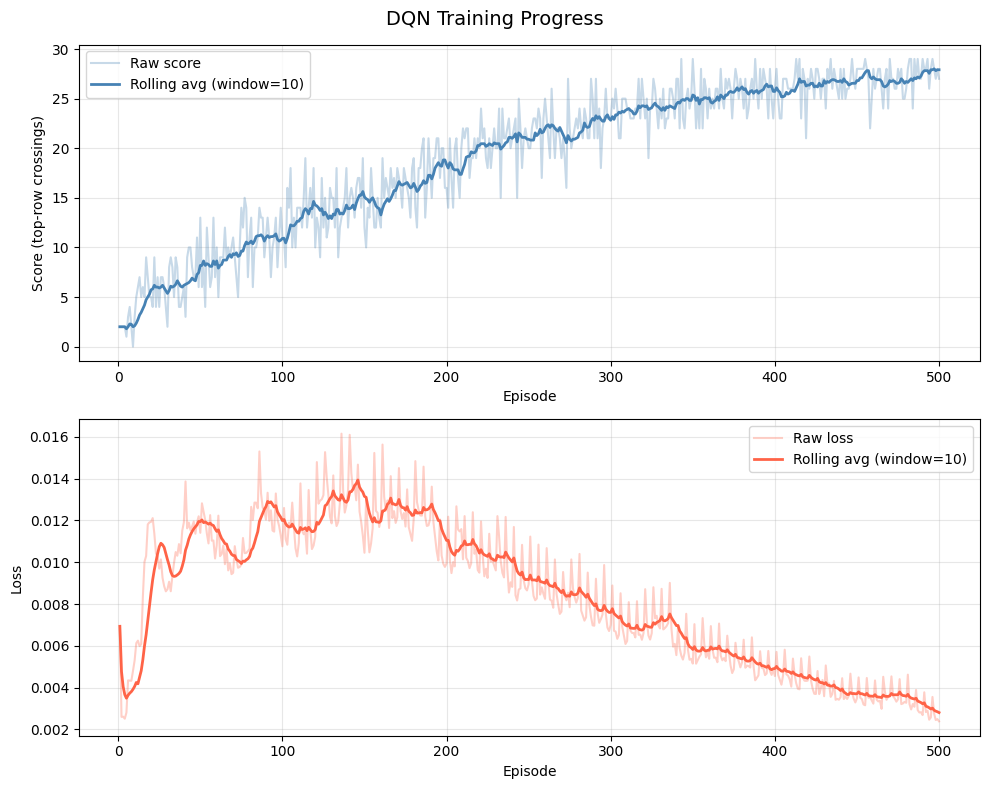

In [ ]:
import matplotlib.pyplot as plt

plot_training(scores_dqn_d0, losses_dqn_d0)

### **Training with heuristic warm-start (Difficulty 1)**

In [ ]:
model_dqn_d1, scores_dqn_d1, losses_dqn_d1 = train_dqn(
    difficulty              = 1,
    n_episodes              = 500,
    buffer_capacity         = 10_000,
    batch_size              = 32,
    warmup_random_steps     = 500,
    warmup_heuristic_ep     = 5,
    target_update_freq      = 500,
    gamma                   = 0.99,
    lr                      = 1e-4,
    epsilon_start           = 0.5,
    epsilon_end             = 0.05,
    epsilon_decay           = 0.995,
    use_per                 = False,
)

torch.save(model_dqn_d1.state_dict(), "model_dqn_d1.pt")
print("model_dqn_d1.pt saved")

[Buffer] Using uniform Replay Buffer.

Phase 1: Buffer warm-start (heuristic)
[Buffer] Heuristic warm-up complete: 3000 transitions stored. Mean heuristic score: 21.0 ± 0.0

Phase 2: Buffer warm-start (random)
[Buffer] Random warm-up complete: 3500 transitions stored.

[Buffer] Total transitions before training: 3500
[Buffer] Training will start once buffer has >= 32 samples (currently: True)

Episode   10 | Score:   4.50 | Loss: 0.0056 | Epsilon: 0.476 | Buffer:   9500 | Steps:    6000
Episode   20 | Score:   8.50 | Loss: 0.0075 | Epsilon: 0.452 | Buffer:  10000 | Steps:   12000
Episode   30 | Score:  10.50 | Loss: 0.0071 | Epsilon: 0.430 | Buffer:  10000 | Steps:   18000
Episode   40 | Score:  10.50 | Loss: 0.0087 | Epsilon: 0.409 | Buffer:  10000 | Steps:   24000
Episode   50 | Score:  10.40 | Loss: 0.0102 | Epsilon: 0.389 | Buffer:  10000 | Steps:   30000
Episode   60 | Score:  12.10 | Loss: 0.0108 | Epsilon: 0.370 | Buffer:  10000 | Steps:   36000
Episode   70 | Score:  12.10 | Lo

### **Plot Training Dificulty 1**

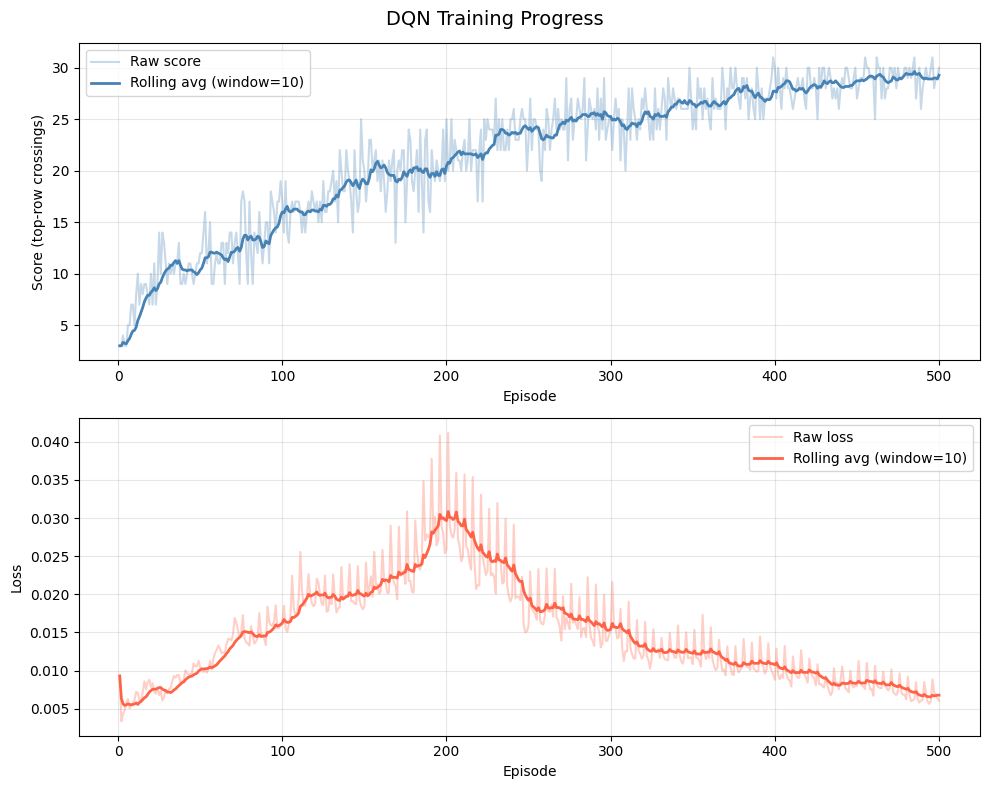

In [ ]:
plot_training(scores_dqn_d1, losses_dqn_d1)

## **Task 2.3 - Target Network Implementation**

### **Soft update**

In [ ]:
def soft_update(primary_net, target_net, tau=0.01):
    """
    Soft update: target = tau * primary + (1 - tau) * target
    Aplicado a cada step de treino em vez de copiar de C em C steps.
    tau pequeno (0.01) → target muda lentamente → targets mais estáveis.
    """
    for target_param, primary_param in zip(target_net.parameters(), primary_net.parameters()):
        target_param.data.copy_(
            tau * primary_param.data + (1.0 - tau) * target_param.data
        )

### **Training loop com suporte a hard/soft update e tracking de Q-values**

In [ ]:
def train_dqn_23(
    difficulty=0,
    n_episodes=500,
    buffer_capacity=10_000,
    batch_size=32,
    warmup_random_steps=500,
    warmup_heuristic_ep=5,
    #Target network
    update_mode="hard",
    target_update_freq=100,
    tau=0.01,
    #Optimização
    gamma=0.99,
    lr=1e-4,
    #Exploração
    epsilon_start=0.5,
    epsilon_end=0.05,
    epsilon_decay=0.995,
    train_freq=1,
    pretrained_path=None,
):
    env = SpaceRaceEnv(obs_mode="rgb", difficulty=difficulty)

    primary_net = DQN(n_actions=2).to(device)
    if pretrained_path is not None:
        primary_net.load_state_dict(torch.load(pretrained_path, map_location=device))
        print(f"[Init] Loaded weights from '{pretrained_path}'")

    target_net = copy.deepcopy(primary_net).to(device)
    target_net.eval()
    for p in target_net.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(primary_net.parameters(), lr=lr)

    buffer = ReplayBuffer(capacity=buffer_capacity)
    print(f"[Target] Update mode: {update_mode.upper()}"
          + (f" | freq={target_update_freq} steps" if update_mode == "hard"
             else f" | tau={tau} (every training step)"))

    print("\nPhase 1: Buffer warm-start (heuristic)")
    populate_buffer_heuristic(buffer, env_difficulty=difficulty,
                               n_episodes=warmup_heuristic_ep)
    print("\nPhase 2: Buffer warm-start (random)")
    populate_buffer_random(buffer, env, n_steps=warmup_random_steps)
    print(f"\n[Buffer] {len(buffer)} transitions before training\n")

    epsilon        = epsilon_start
    episode_scores = []
    episode_losses = []
    episode_mean_q = []
    total_steps    = 0
    start_time     = time.time()

    for episode in range(n_episodes):
        obs, info = env.reset()
        done         = False
        total_loss   = 0.0
        total_q      = 0.0
        update_count = 0

        while not done:
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    obs_t  = torch.FloatTensor(obs).unsqueeze(0).to(device)
                    q_vals = primary_net(obs_t)
                    action = q_vals.argmax(dim=1).item()
                    total_q += q_vals.max().item()
                    del obs_t, q_vals

            next_obs, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated

            buffer.add(obs, action, reward, next_obs, float(done))
            obs   = next_obs
            info  = next_info
            total_steps += 1

            if buffer.is_ready(batch_size) and (total_steps % train_freq == 0):
                batch = buffer.sample(batch_size)
                loss, _, _ = compute_loss_dqn(primary_net, target_net, batch, gamma)

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(primary_net.parameters(), max_norm=1.0)
                optimizer.step()

                total_loss   += loss.item()
                update_count += 1
                del loss

                #Soft update: aplica a cada step de treino
                if update_mode == "soft":
                    soft_update(primary_net, target_net, tau=tau)

            #Hard update: aplica de C em C steps
            if update_mode == "hard" and total_steps % target_update_freq == 0:
                target_net.load_state_dict(primary_net.state_dict())
                target_net.eval()
                for p in target_net.parameters():
                    p.requires_grad = False

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        episode_scores.append(info['score'])
        episode_losses.append(total_loss / update_count if update_count > 0 else 0.0)
        episode_mean_q.append(total_q / update_count if update_count > 0 else 0.0)

        if (episode + 1) % 50 == 0:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if (episode + 1) % 10 == 0:
            elapsed = time.time() - start_time
            print(f"Episode {episode+1:4d} | "
                  f"Score: {np.mean(episode_scores[-10:]):6.2f} | "
                  f"Loss: {np.mean(episode_losses[-10:]):.4f} | "
                  f"MeanQ: {np.mean(episode_mean_q[-10:]):6.3f} | "
                  f"Epsilon: {epsilon:.3f} | "
                  f"Time: {elapsed/60:.1f}min")

        if (episode + 1) % 200 == 0:
            ckpt = f"model_23_{update_mode}_d{difficulty}_ep{episode+1}.pt"
            torch.save(primary_net.state_dict(), ckpt)
            elapsed = time.time() - start_time
            h, m, s = int(elapsed//3600), int((elapsed%3600)//60), int(elapsed%60)
            print(f"[Checkpoint] Saved '{ckpt}' | Elapsed: {h:02d}:{m:02d}:{s:02d}")

    elapsed_total = time.time() - start_time
    return primary_net, episode_scores, episode_losses, episode_mean_q, elapsed_total

### **Hard update para D0 e D1**

In [ ]:
model_hard_d0, scores_hard_d0, losses_hard_d0, q_hard_d0, time_hard_d0 = train_dqn_23(
    difficulty          = 0,
    n_episodes          = 500,
    update_mode         = "hard",
    target_update_freq  = 100,
)
torch.save(model_hard_d0.state_dict(), "model_hard_d0.pt")
print(f"model_hard_d0.pt saved | Total time: {time_hard_d0/60:.1f} min")

model_hard_d1, scores_hard_d1, losses_hard_d1, q_hard_d1, time_hard_d1 = train_dqn_23(
    difficulty          = 1,
    n_episodes          = 500,
    update_mode         = "hard",
    target_update_freq  = 100,
)
torch.save(model_hard_d1.state_dict(), "model_hard_d1.pt")
print(f"model_hard_d1.pt saved | Total time: {time_hard_d1/60:.1f} min")

HARD UPDATE — Difficulty 0
[Target] Update mode: HARD | freq=100 steps

Phase 1: Buffer warm-start (heuristic)
[Buffer] Heuristic warm-up complete: 3000 transitions stored. Mean heuristic score: 22.0 ± 0.0

Phase 2: Buffer warm-start (random)
[Buffer] Random warm-up complete: 3500 transitions stored.

[Buffer] 3500 transitions before training

Episode   10 | Score:   2.70 | Loss: 0.0153 | MeanQ:  0.643 | Epsilon: 0.476 | Time: 0.5min
Episode   20 | Score:   4.80 | Loss: 0.0231 | MeanQ:  1.857 | Epsilon: 0.452 | Time: 1.0min
Episode   30 | Score:   6.00 | Loss: 0.0285 | MeanQ:  2.610 | Epsilon: 0.430 | Time: 1.5min
Episode   40 | Score:   6.90 | Loss: 0.0332 | MeanQ:  3.068 | Epsilon: 0.409 | Time: 2.0min
Episode   50 | Score:   6.10 | Loss: 0.0369 | MeanQ:  3.263 | Epsilon: 0.389 | Time: 2.5min
Episode   60 | Score:   6.80 | Loss: 0.0361 | MeanQ:  3.513 | Epsilon: 0.370 | Time: 3.0min
Episode   70 | Score:   8.60 | Loss: 0.0420 | MeanQ:  3.946 | Epsilon: 0.352 | Time: 3.5min
Episode   

### **Soft update D0 e D1**

In [ ]:
model_soft_d0, scores_soft_d0, losses_soft_d0, q_soft_d0, time_soft_d0 = train_dqn_23(
    difficulty   = 0,
    n_episodes   = 500,
    update_mode  = "soft",
    tau          = 0.01,
)
torch.save(model_soft_d0.state_dict(), "model_soft_d0.pt")
print(f"model_soft_d0.pt saved | Total time: {time_soft_d0/60:.1f} min")

model_soft_d1, scores_soft_d1, losses_soft_d1, q_soft_d1, time_soft_d1 = train_dqn_23(
    difficulty   = 1,
    n_episodes   = 500,
    update_mode  = "soft",
    tau          = 0.01,
)
torch.save(model_soft_d1.state_dict(), "model_soft_d1.pt")
print(f"model_soft_d1.pt saved | Total time: {time_soft_d1/60:.1f} min")

SOFT UPDATE — Difficulty 0
[Target] Update mode: SOFT | tau=0.01 (every training step)

Phase 1: Buffer warm-start (heuristic)
[Buffer] Heuristic warm-up complete: 3000 transitions stored. Mean heuristic score: 22.0 ± 0.0

Phase 2: Buffer warm-start (random)
[Buffer] Random warm-up complete: 3500 transitions stored.

[Buffer] 3500 transitions before training

Episode   10 | Score:   3.50 | Loss: 0.0096 | MeanQ:  0.627 | Epsilon: 0.476 | Time: 0.6min
Episode   20 | Score:   4.00 | Loss: 0.0176 | MeanQ:  1.818 | Epsilon: 0.452 | Time: 1.1min
Episode   30 | Score:   6.50 | Loss: 0.0203 | MeanQ:  2.666 | Epsilon: 0.430 | Time: 1.7min
Episode   40 | Score:   5.40 | Loss: 0.0224 | MeanQ:  3.063 | Epsilon: 0.409 | Time: 2.2min
Episode   50 | Score:   6.20 | Loss: 0.0210 | MeanQ:  3.357 | Epsilon: 0.389 | Time: 2.8min
Episode   60 | Score:   7.50 | Loss: 0.0205 | MeanQ:  3.516 | Epsilon: 0.370 | Time: 3.3min
Episode   70 | Score:   9.00 | Loss: 0.0182 | MeanQ:  3.674 | Epsilon: 0.352 | Time: 3

In [ ]:
model_hard_d2, scores_hard_d2, losses_hard_d2, q_hard_d2, time_hard_d2 = train_dqn_23(
    difficulty          = 2,
    n_episodes          = 500,
    update_mode         = "hard",
    target_update_freq  = 100,
)
torch.save(model_hard_d2.state_dict(), "model_hard_d2.pt")
print(f"model_hard_d2.pt saved | Total time: {time_hard_d2/60:.1f} min")

model_soft_d2, scores_soft_d2, losses_soft_d2, q_soft_d2, time_soft_d2 = train_dqn_23(
    difficulty   = 2,
    n_episodes   = 500,
    update_mode  = "soft",
    tau          = 0.01,
)
torch.save(model_soft_d2.state_dict(), "model_soft_d2.pt")
print(f"model_soft_d2.pt saved | Total time: {time_soft_d2/60:.1f} min")

[Target] Update mode: HARD | freq=100 steps

Phase 1: Buffer warm-start (heuristic)
[Buffer] Heuristic warm-up complete: 3000 transitions stored. Mean heuristic score: 13.2 ± 3.2

Phase 2: Buffer warm-start (random)
[Buffer] Random warm-up complete: 3500 transitions stored.

[Buffer] 3500 transitions before training

Episode   10 | Score:   4.00 | Loss: 0.0154 | MeanQ:  0.491 | Epsilon: 0.476 | Time: 0.5min
Episode   20 | Score:   4.30 | Loss: 0.0272 | MeanQ:  1.480 | Epsilon: 0.452 | Time: 1.0min
Episode   30 | Score:   5.10 | Loss: 0.0386 | MeanQ:  2.365 | Epsilon: 0.430 | Time: 1.5min
Episode   40 | Score:   4.60 | Loss: 0.0514 | MeanQ:  2.962 | Epsilon: 0.409 | Time: 2.1min
Episode   50 | Score:   6.70 | Loss: 0.0619 | MeanQ:  3.465 | Epsilon: 0.389 | Time: 2.6min
Episode   60 | Score:   8.60 | Loss: 0.0667 | MeanQ:  3.829 | Epsilon: 0.370 | Time: 3.1min
Episode   70 | Score:   9.40 | Loss: 0.0642 | MeanQ:  4.013 | Epsilon: 0.352 | Time: 3.6min
Episode   80 | Score:   8.90 | Loss: 

### **Evaluation and Comparison**

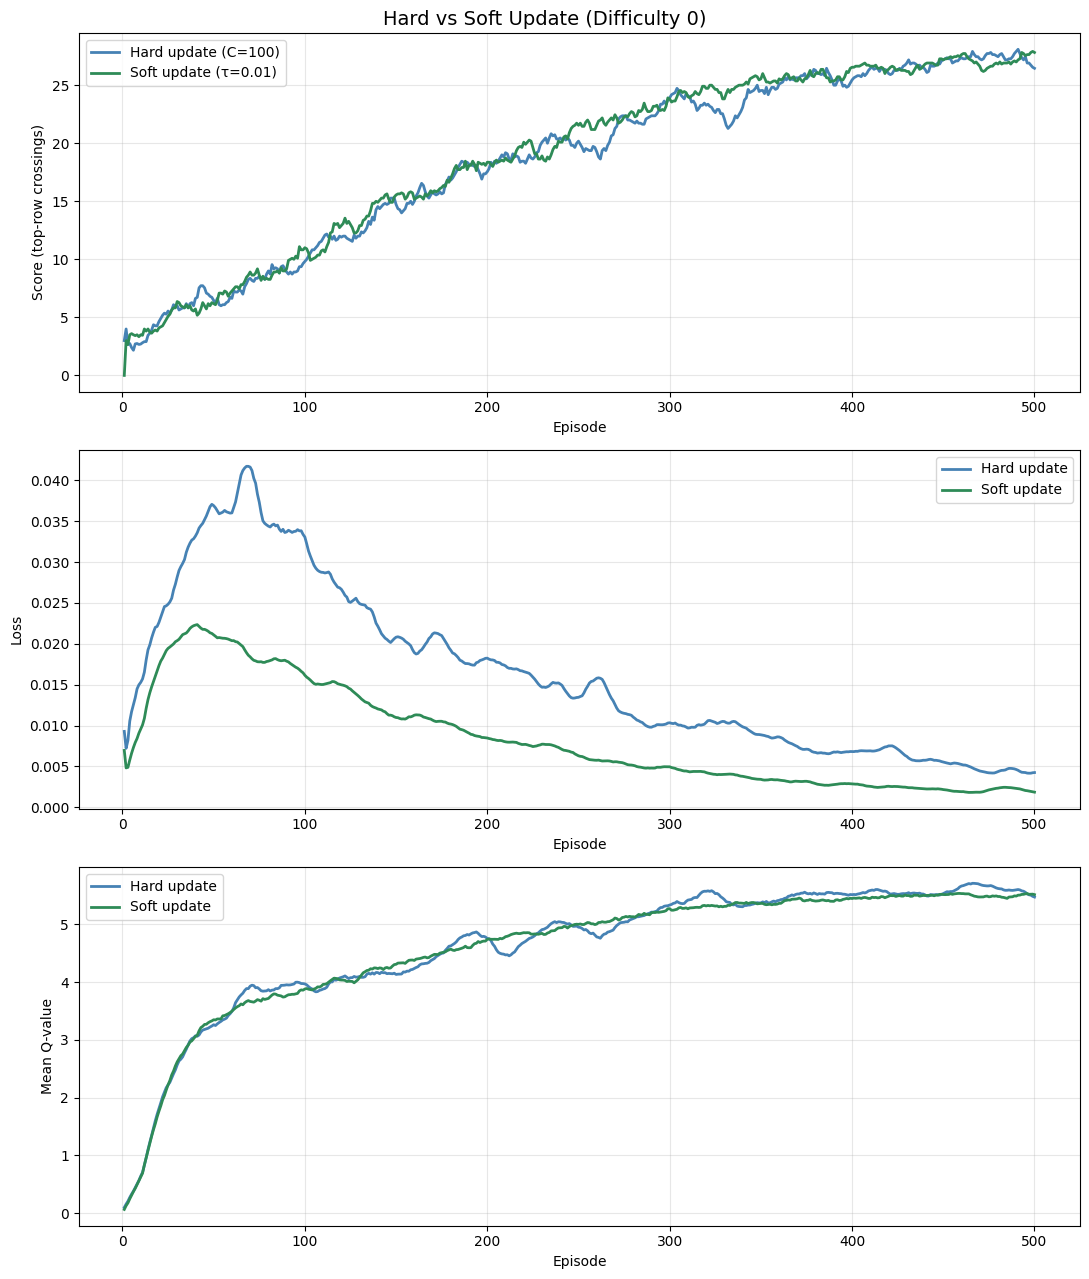

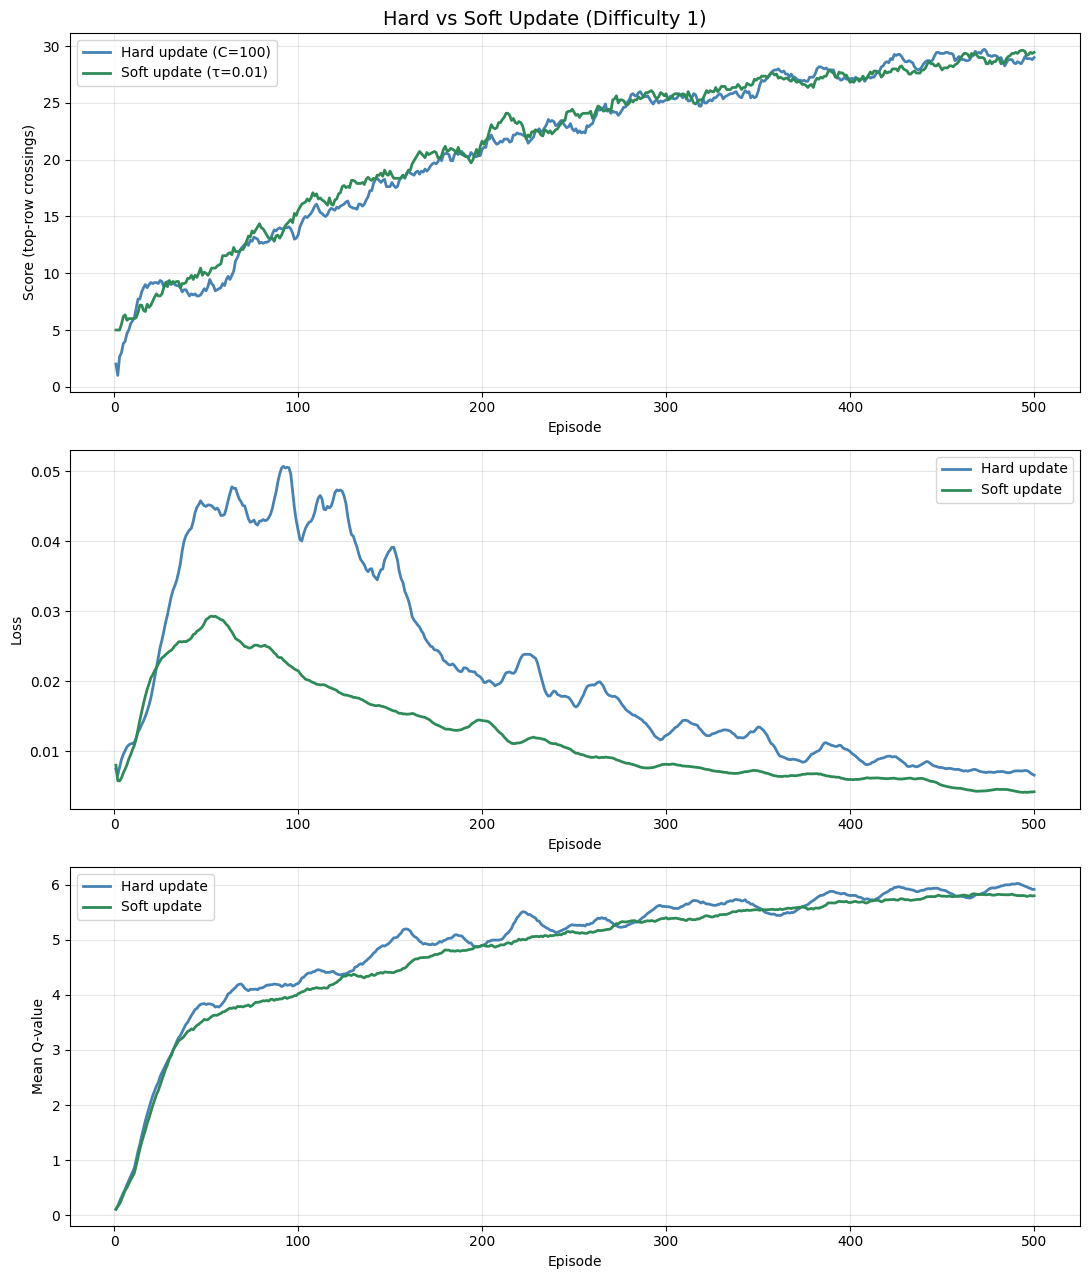

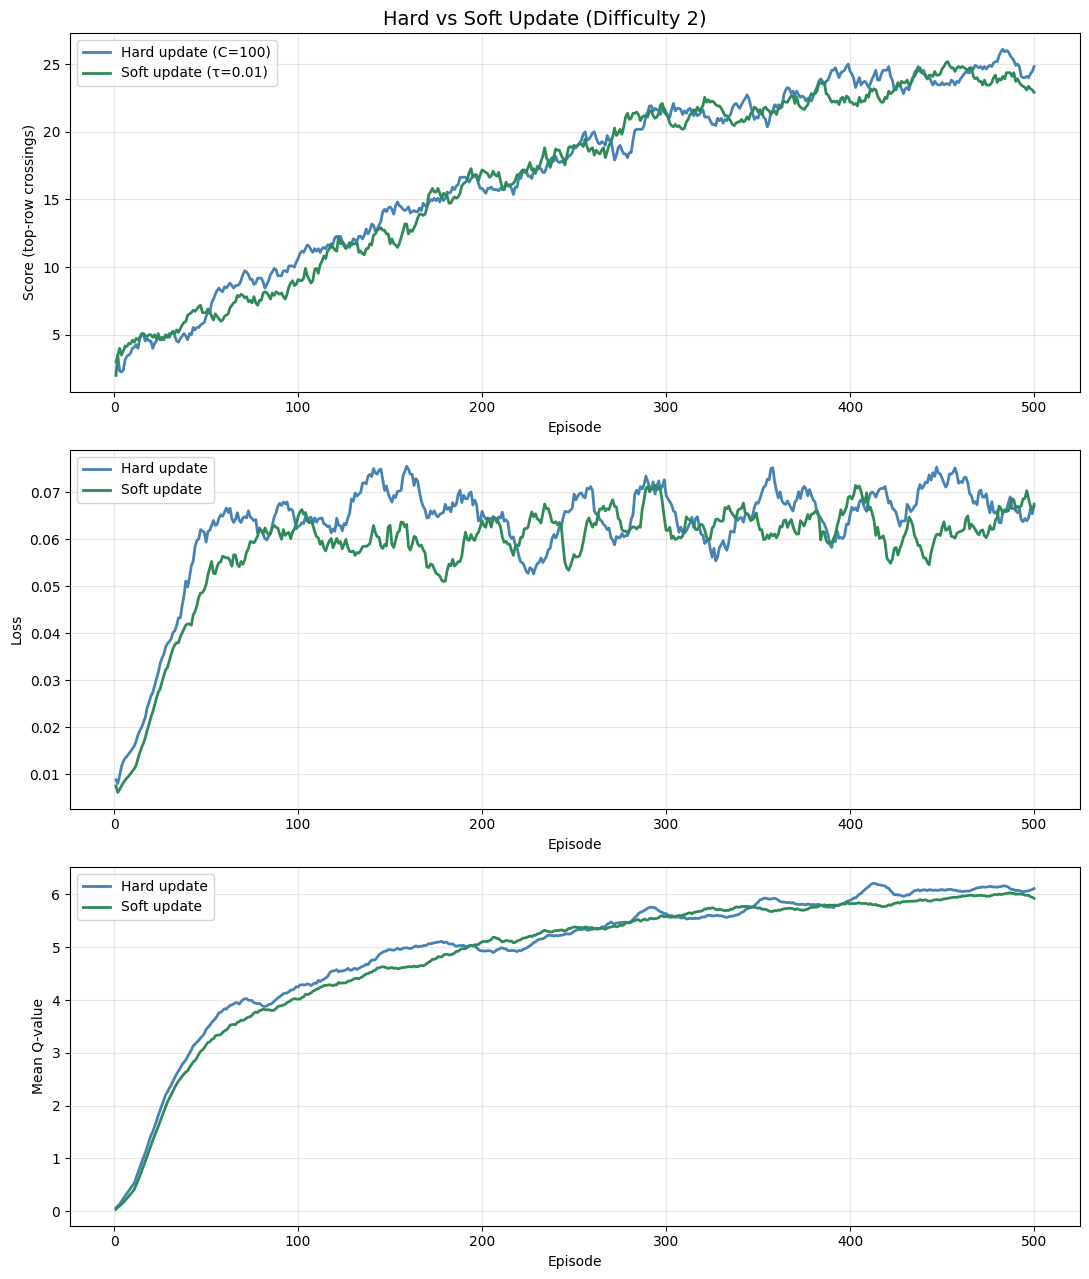


EFFICIENCY TABLE — Score / Training Time  &  Q-value / Training Time
Config        FinalScore    MeanQ  Time(min)  Score/min    Q/min
----------------------------------------------------------------------
Hard  D0           27.20    5.529       26.2      1.038   0.2109
Hard  D1           28.80    5.964       26.0      1.108   0.2295
Hard  D2           24.95    6.099       26.6      0.939   0.2295
Soft  D0           27.45    5.507       28.7      0.958   0.1921
Soft  D1           29.35    5.799       28.0      1.047   0.2069
Soft  D2           23.65    5.974       28.7      0.825   0.2085


In [ ]:
def plot_comparison_23(scores_hard, scores_soft, losses_hard, losses_soft,
                        q_hard, q_soft, difficulty, window=10):
    def rolling_avg(data, w):
        return [np.mean(data[max(0, i-w):i+1]) for i in range(len(data))]

    ep = range(1, len(scores_hard) + 1)

    fig, axes = plt.subplots(3, 1, figsize=(11, 13))
    fig.suptitle(f"Hard vs Soft Update (Difficulty {difficulty})", fontsize=14)

    # Score
    axes[0].plot(ep, rolling_avg(scores_hard, window), color="steelblue",
                 linewidth=2, label="Hard update (C=100)")
    axes[0].plot(ep, rolling_avg(scores_soft, window), color="seagreen",
                 linewidth=2, label="Soft update (τ=0.01)")
    axes[0].set_ylabel("Score (top-row crossings)")
    axes[0].set_xlabel("Episode")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(ep, rolling_avg(losses_hard, window), color="steelblue",
                 linewidth=2, label="Hard update")
    axes[1].plot(ep, rolling_avg(losses_soft, window), color="seagreen",
                 linewidth=2, label="Soft update")
    axes[1].set_ylabel("Loss")
    axes[1].set_xlabel("Episode")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Mean Q-value
    axes[2].plot(ep, rolling_avg(q_hard, window), color="steelblue",
                 linewidth=2, label="Hard update")
    axes[2].plot(ep, rolling_avg(q_soft, window), color="seagreen",
                 linewidth=2, label="Soft update")
    axes[2].set_ylabel("Mean Q-value")
    axes[2].set_xlabel("Episode")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Plots D0
plot_comparison_23(scores_hard_d0, scores_soft_d0,
                   losses_hard_d0, losses_soft_d0,
                   q_hard_d0, q_soft_d0, difficulty=0)

# Plots D1
plot_comparison_23(scores_hard_d1, scores_soft_d1,
                   losses_hard_d1, losses_soft_d1,
                   q_hard_d1, q_soft_d1, difficulty=1)

# Plots D2
plot_comparison_23(scores_hard_d2, scores_soft_d2,
                   losses_hard_d2, losses_soft_d2,
                   q_hard_d2, q_soft_d2, difficulty=2)

# Tabela de eficiência (score/time e Q/time — o enunciado pede explicitamente)
print("\n" + "=" * 70)
print("EFFICIENCY TABLE — Score / Training Time  &  Q-value / Training Time")
print("=" * 70)

configs = [
    ("Hard  D0", scores_hard_d0, q_hard_d0, time_hard_d0),
    ("Hard  D1", scores_hard_d1, q_hard_d1, time_hard_d1),
    ("Hard  D2", scores_hard_d2, q_hard_d2, time_hard_d2),
    ("Soft  D0", scores_soft_d0, q_soft_d0, time_soft_d0),
    ("Soft  D1", scores_soft_d1, q_soft_d1, time_soft_d1),
    ("Soft  D2", scores_soft_d2, q_soft_d2, time_soft_d2),
]

print(f"{'Config':<12} {'FinalScore':>11} {'MeanQ':>8} {'Time(min)':>10} "
      f"{'Score/min':>10} {'Q/min':>8}")
print("-" * 70)
for name, scores, qs, t in configs:
    final_score = np.mean(scores[-20:])
    mean_q      = np.mean(qs[-20:])
    t_min       = t / 60
    print(f"{name:<12} {final_score:>11.2f} {mean_q:>8.3f} {t_min:>10.1f} "
          f"{final_score/t_min:>10.3f} {mean_q/t_min:>8.4f}")

### **Submission**

In [ ]:
agent_code = '''
from __future__ import annotations
import numpy as np
import torch
import torch.nn as nn
import os


class DQN(nn.Module):
    def __init__(self, n_actions=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 13 * 9, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = x / 255.0
        x = self.conv(x)
        x = x.flatten(start_dim=1)
        return self.fc(x)


class Agent:
    def __init__(self) -> None:
        self.device = torch.device("cpu")   # avaliador não tem GPU garantida
        self.model  = DQN(n_actions=2).to(self.device)

        # Carrega o modelo — ficheiro .pt tem de estar no mesmo ZIP
        model_path = os.path.join(os.path.dirname(__file__), "model_best.pt")
        self.model.load_state_dict(
            torch.load(model_path, map_location=self.device)
        )
        self.model.eval()

    def select_action(self, obs: np.ndarray) -> int:
        with torch.no_grad():
            obs_t   = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
            q_vals  = self.model(obs_t)
            return int(q_vals.argmax(dim=1).item())
'''

with open("agent.py", "w") as f:
    f.write(agent_code)
print("agent.py written")

agent.py written


In [ ]:
import shutil
shutil.copy("model_hard_d2.pt", "model_best.pt")

!zip submission_task23.zip agent.py model_best.pt
print("submission_task23.zip done")

updating: agent.py (deflated 57%)
updating: model_best.pt (deflated 7%)
submission_task23.zip done


##Test Like CodaBench

In [ ]:
!python local_eval.py --difficulty 2

  Episode  1/10  →  score = 26
  Episode  2/10  →  score = 30
  Episode  3/10  →  score = 29
  Episode  4/10  →  score = 26
  Episode  5/10  →  score = 26
  Episode  6/10  →  score = 29
  Episode  7/10  →  score = 27
  Episode  8/10  →  score = 22
  Episode  9/10  →  score = 25
  Episode 10/10  →  score = 26

--- Results (difficulty=2) ---
  Mean : 26.60
  Std  : 2.20
  Min  : 22
  Max  : 30



# **Task 3: Exploration Strategies**

Comparison of two exploration strategies for the DQN agent:

1. **Epsilon-Greedy** with three decay schedules (exponential, linear, step-based) and two initial values.
2. **Boltzmann Exploration** (softmax over Q-values) with three temperature schedules.

All experiments reuse the Task 2.3 infrastructure (uniform Replay Buffer + Target Network with soft updates), keeping every variable identical *except* the action-selection mechanism. This isolates the effect of exploration cleanly.

## Task 3.1. $\epsilon$-Greedy Action Selection

- **With probability $\epsilon$** $\rightarrow$ random action *(exploration)*
- **Otherwise** $\rightarrow \arg\max_a Q(s, a)$ *(exploitation)*

In [ ]:
def select_action_epsilon_greedy(model, obs, epsilon, n_actions=2):
    """
    Standard ε-greedy action selection.

    Returns:
        action (int): chosen action
        was_random (bool): True if action came from exploration (for tracking)
    """
    if np.random.random() < epsilon:
        # Exploration: uniform random action
        return np.random.randint(n_actions), True
    else:
        # Exploitation: greedy with respect to Q-values
        with torch.no_grad():
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            q_vals = model(obs_t)
            return int(q_vals.argmax(dim=1).item()), False


# DECAY SCHEDULES for epsilon
# Three schedules implemented - each receives the episode index and returns the epsilon value for that episode.
# This makes the schedule decoupled from the training loop and easy to plot/inspect.

def epsilon_exponential(episode, eps_start=1.0, eps_end=0.05, decay=0.995):
    """Multiplicative decay: ε ← max(ε_end, ε_start · decay^episode).
    Smooth, gradual reduction — the most common choice in DQN papers."""
    return max(eps_end, eps_start * (decay ** episode))


def epsilon_linear(episode, eps_start=1.0, eps_end=0.05, decay_episodes=400):
    """Linear interpolation from ε_start to ε_end over `decay_episodes` episodes,
    then held constant. Predictable and easy to reason about."""
    frac = min(1.0, episode / decay_episodes)
    return eps_start + (eps_end - eps_start) * frac


def epsilon_step(episode, eps_start=1.0, eps_end=0.05,
                 milestones=(100, 250, 400), factor=0.3):
    """Step-based decay: epsilon is multiplied by `factor` whenever a milestone
    is reached. Models the idea of distinct training 'phases'."""
    eps = eps_start
    for m in milestones:
        if episode >= m:
            eps *= factor
    return max(eps_end, eps)

## Task 3.2 - Boltzmann Action Selection

Instead of $\epsilon$-greedy's "explore or exploit" dichotomy, Boltzmann samples actions proportionally to $\exp(Q(s,a) / \tau)$:

$$
\pi(a \mid s) = \frac{\exp(Q(s,a) / \tau)}{\sum_b \exp(Q(s,b) / \tau)}
$$

### Intuition:
- **High $\tau$** $\rightarrow$ distribution is flat $\rightarrow$ near-uniform exploration
- **Low $\tau$** $\rightarrow$ distribution peaks on argmax $\rightarrow$ near-greedy exploitation
- **$\tau \rightarrow 0$** recovers pure greedy; **$\tau \rightarrow \infty$** recovers uniform random

**Key advantage over $\epsilon$-greedy:** Exploration is *Q-aware*. A clearly bad action is rarely picked even during exploration — unlike $\epsilon$-greedy, which treats all non-greedy actions equally.\

In [ ]:
def select_action_boltzmann(model, obs, temperature, n_actions=2):
    """
    Boltzmann action selection with numerically stable softmax.

    Returns:
        action (int): chosen action
        entropy (float): policy entropy in nats — exploration intensity
                         (≈ log(2) ≈ 0.693 when fully exploring,
                          ≈ 0     when fully exploiting)
    """
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        q_vals = model(obs_t).squeeze(0)        # shape: (n_actions,)

        # Subtract max for numerical stability (standard softmax trick).
        # Without this, very small temperatures cause exp() to overflow.
        scaled = q_vals / max(temperature, 1e-8)
        scaled = scaled - scaled.max()
        probs = torch.softmax(scaled, dim=0)

        # Sample from the categorical distribution
        action = torch.multinomial(probs, num_samples=1).item()

        # Compute entropy for tracking how exploratory the policy is
        log_probs = torch.log(probs + 1e-12)
        entropy = -(probs * log_probs).sum().item()

    return int(action), float(entropy)



# TEMPERATURE SCHEDULES
# Three schedules analogous to the epsilon ones - symmetry makes the
# later comparison cleaner.

def temperature_exponential(episode, tau_start=1.0, tau_end=0.05, decay=0.995):
    """Exponential decay — direct analogue of epsilon_exponential."""
    return max(tau_end, tau_start * (decay ** episode))


def temperature_linear(episode, tau_start=1.0, tau_end=0.05, decay_episodes=400):
    """Linear decay over `decay_episodes`, then constant."""
    frac = min(1.0, episode / decay_episodes)
    return tau_start + (tau_end - tau_start) * frac


def temperature_step(episode, tau_start=1.0, tau_end=0.05,
                     milestones=(100, 250, 400), factor=0.3):
    """Step-wise decay — direct analogue of epsilon_step."""
    tau = tau_start
    for m in milestones:
        if episode >= m:
            tau *= factor
    return max(tau_end, tau)

In [ ]:
# UNIFIED TRAINING LOOP
# Reuses Task 2.3 infrastructure (ReplayBuffer + Target Network + soft updates + compute_loss_dqn).
# The ONLY thing that changes between experiments is the action-selection function: this isolates the effect of exploration cleanly.

def train_dqn_exploration(
    strategy,               # "epsilon" or "boltzmann"
    schedule_fn,            # function(episode) -> epsilon OR temperature
    difficulty=1,
    n_episodes=500,
    gamma=0.99,
    lr=1e-4,
    batch_size=32,
    buffer_capacity=10_000,
    train_freq=1,
    tau=0.005,              # soft update coefficient
    warmup_steps=1_000,     # random transitions before training starts
    label="run",
):
    env = SpaceRaceEnv(obs_mode="rgb", difficulty=difficulty)

    # Primary + target networks (Task 2.3 setup)
    primary_net = DQN(n_actions=2).to(device)
    target_net  = DQN(n_actions=2).to(device)
    target_net.load_state_dict(primary_net.state_dict())
    target_net.eval()
    for p in target_net.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(primary_net.parameters(), lr=lr)
    buffer    = ReplayBuffer(capacity=buffer_capacity)

    # Random buffer warm-up
    # No heuristic warm-up here: it would taint the comparison of
    # exploration strategies with an external prior.
    obs, info = env.reset()
    for _ in range(warmup_steps):
        action = env.action_space.sample()
        next_obs, reward, term, trunc, next_info = env.step(action)
        done = term or trunc
        buffer.add(obs, action, reward, next_obs, float(done))
        if done:
            obs, info = env.reset()
        else:
            obs, info = next_obs, next_info

    # Metric tracking
    episode_scores, episode_losses, episode_mean_q = [], [], []
    episode_param, episode_explore = [], []
    total_steps = 0
    start_time  = time.time()

    for episode in range(n_episodes):
        param_value = schedule_fn(episode)
        obs, info = env.reset()
        done = False

        ep_loss = ep_q = ep_explore_signal = 0.0
        ep_updates = ep_steps = 0

        while not done:
            # Action selection
            if strategy == "epsilon":
                action, was_random = select_action_epsilon_greedy(
                    primary_net, obs, param_value)
                ep_explore_signal += float(was_random)
            else:  # boltzmann
                action, entropy = select_action_boltzmann(
                    primary_net, obs, param_value)
                ep_explore_signal += entropy

            next_obs, reward, term, trunc, next_info = env.step(action)
            done = term or trunc
            buffer.add(obs, action, reward, next_obs, float(done))

            # Track Q-value of the chosen action
            with torch.no_grad():
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                ep_q += primary_net(obs_t)[0, action].item()

            obs = next_obs
            info = next_info
            total_steps += 1
            ep_steps    += 1

            # Gradient update
            if buffer.is_ready(batch_size) and (total_steps % train_freq == 0):
                batch = buffer.sample(batch_size)
                loss, _, _ = compute_loss_dqn(primary_net, target_net, batch, gamma)

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(primary_net.parameters(), max_norm=1.0)
                optimizer.step()

                ep_loss += loss.item()
                ep_updates += 1

                soft_update(primary_net, target_net, tau=tau)

        episode_scores.append(info['score'])
        episode_losses.append(ep_loss / ep_updates if ep_updates > 0 else 0.0)
        episode_mean_q.append(ep_q / ep_steps if ep_steps > 0 else 0.0)
        episode_param.append(param_value)
        episode_explore.append(ep_explore_signal / ep_steps if ep_steps > 0 else 0.0)

        if (episode + 1) % 25 == 0:
            elapsed = (time.time() - start_time) / 60
            print(f"[{label}] Ep {episode+1:4d} | "
                  f"Score: {np.mean(episode_scores[-25:]):6.2f} | "
                  f"Loss: {np.mean(episode_losses[-25:]):.4f} | "
                  f"Q: {np.mean(episode_mean_q[-25:]):6.3f} | "
                  f"{'ε' if strategy=='epsilon' else 'τ'}: {param_value:.3f} | "
                  f"Explore: {np.mean(episode_explore[-25:]):.3f} | "
                  f"Time: {elapsed:.1f}min")

    elapsed_total = time.time() - start_time
    return {
        "label":       label,
        "strategy":    strategy,
        "scores":      episode_scores,
        "losses":      episode_losses,
        "mean_q":      episode_mean_q,
        "param":       episode_param,
        "explore":     episode_explore,
        "time_min":    elapsed_total / 60,
        "model_state": primary_net.state_dict(),
    }

In [ ]:
# EXPERIMENTAL DESIGN
# 6 main runs: 3 ε schedules + 3 τ schedules (decay shape comparison)
# 2 extra runs: lower initial ε / τ (hyperparameter sensitivity)
# All runs: difficulty=1, 500 episodes - directly comparable to Task 2.3.

# Each run is saved to Google Drive immediately after training (model .pt + metrics .json).
# If the session expires, just re-run this cell: completed runs are skipped and training resumes where it stopped.

import os, json
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

SAVE_DIR = "/content/drive/MyDrive/task3"
os.makedirs(SAVE_DIR, exist_ok=True)

N_EPISODES = 500
DIFFICULTY = 1

runs = [
    ("eps_exponential",     "epsilon",   lambda ep: epsilon_exponential(ep, 1.0, 0.05, 0.995),       "eps_exp"),
    ("eps_linear",          "epsilon",   lambda ep: epsilon_linear(ep, 1.0, 0.05, 400),              "eps_lin"),
    ("eps_step",            "epsilon",   lambda ep: epsilon_step(ep, 1.0, 0.05, (100,250,400), 0.3), "eps_step"),
    ("boltz_exponential",   "boltzmann", lambda ep: temperature_exponential(ep, 1.0, 0.05, 0.995),       "boltz_exp"),
    ("boltz_linear",        "boltzmann", lambda ep: temperature_linear(ep, 1.0, 0.05, 400),              "boltz_lin"),
    ("boltz_step",          "boltzmann", lambda ep: temperature_step(ep, 1.0, 0.05, (100,250,400), 0.3), "boltz_step"),
    ("eps_exp_low_start",   "epsilon",   lambda ep: epsilon_exponential(ep, 0.5, 0.05, 0.995),       "eps_exp_0.5"),
    ("boltz_exp_low_start", "boltzmann", lambda ep: temperature_exponential(ep, 0.5, 0.05, 0.995),       "boltz_exp_0.5"),
]

experiments = {}

for name, strategy, schedule_fn, label in runs:
    model_path  = os.path.join(SAVE_DIR, f"model_task3_{name}.pt")
    metric_path = os.path.join(SAVE_DIR, f"metrics_task3_{name}.json")

    if os.path.exists(model_path) and os.path.exists(metric_path):
        print(f"[SKIP] {name} already saved — loading metrics.")
        with open(metric_path) as f:
            experiments[name] = json.load(f)
        continue

    print(f"\n{'='*60}\n[RUN] {name}\n{'='*60}")
    exp = train_dqn_exploration(strategy, schedule_fn, DIFFICULTY, N_EPISODES, label=label)

    torch.save(exp["model_state"], model_path)
    with open(metric_path, "w") as f:
        json.dump({k: v for k, v in exp.items() if k != "model_state"}, f)
    print(f"[SAVED] {name}")

    experiments[name] = exp

print("\nAll runs complete and saved to Drive.")

Mounted at /content/drive
[SKIP] eps_exponential already saved — loading metrics.
[SKIP] eps_linear already saved — loading metrics.
[SKIP] eps_step already saved — loading metrics.
[SKIP] boltz_exponential already saved — loading metrics.
[SKIP] boltz_linear already saved — loading metrics.
[SKIP] boltz_step already saved — loading metrics.
[SKIP] eps_exp_low_start already saved — loading metrics.
[SKIP] boltz_exp_low_start already saved — loading metrics.

All runs complete and saved to Drive.


## Task 3.3 - Comparative Analysis

Five metrics required:
1. Learning Efficiency: episodes to reach target score
2. Final Performance: mean of last 50 episodes
3. Exploration Behavior: see Plot C
4. Stability: std of last 50 episodes
5. Hyperparameter Sensitivity: initial-value sweep

In [ ]:
import matplotlib.pyplot as plt

def rolling_avg(data, window=20):
    return [np.mean(data[max(0, i - window):i + 1]) for i in range(len(data))]

print("=" * 100)
print(f"{'Experiment':<22} {'FinalScore':>11} {'StdLast50':>10} "
      f"{'MeanQ':>8} {'EpisToHit15':>12} {'Time(min)':>10}")
print("-" * 100)

TARGET_SCORE = 15.0
summary = {}
for name, exp in experiments.items():
    scores = np.array(exp["scores"])
    smooth = np.array(rolling_avg(scores, 20))

    final_score = scores[-50:].mean()
    std_last50  = scores[-50:].std()
    mean_q      = np.mean(exp["mean_q"][-50:])

    hit = np.where(smooth >= TARGET_SCORE)[0]
    eps_to_hit = int(hit[0]) if len(hit) else -1

    summary[name] = dict(final=final_score, std=std_last50, q=mean_q,
                         hit=eps_to_hit, time=exp["time_min"])
    print(f"{name:<22} {final_score:>11.2f} {std_last50:>10.2f} "
          f"{mean_q:>8.3f} {eps_to_hit:>12d} {exp['time_min']:>10.1f}")
print("=" * 100)

Experiment              FinalScore  StdLast50    MeanQ  EpisToHit15  Time(min)
----------------------------------------------------------------------------------------------------
eps_exponential              26.30       1.90    6.004          217       31.2
eps_linear                   28.96       1.44    6.036          277       31.0
eps_step                     28.76       1.63    6.069          120       31.1
boltz_exponential            21.30       1.78    6.062          397       34.2
boltz_linear                 28.76       1.05    6.174          364       34.3
boltz_step                   28.94       1.01    6.136          259       34.4
eps_exp_low_start            29.08       1.35    6.095           97       32.0
boltz_exp_low_start          28.68       1.05    6.118          252       33.7


**Comments:**

* **Learning speed:** Epsilon-greedy learns much faster than Boltzmann. The ε runs reached score 15 at episodes 217/277/120, while Boltzmann needed 397/364/259 episodes. With only 2 actions, Boltzmann keeps choosing actions almost randomly for a longer time, because the softmax probabilities stay close to equal until τ becomes small. In contrast, ε-greedy starts using the best action much earlier.

* **Final performance:** Both methods reached very similar final scores (most runs between 28.7 and 29.1). The only weaker result was `boltz_exponential` (21.30), which did not recover from its slow start within 500 episodes. Mean Q-values were also similar (6.00-6.17), showing that all methods learned value functions of similar size. The main difference is in the quality of the final policy.

* **Training time:** Boltzmann was slower in every run (~34 min compared to ~31 min for ε-greedy). This is because Boltzmann must calculate softmax probabilities and sample actions at every step, while ε-greedy only needs an argmax or a random choice.

* **Exploration behaviour:** ε-greedy explores randomly, so both actions have the same chance when exploring. Boltzmann uses Q-values, so worse actions are chosen less often. However, with only 2 actions, this advantage is very small because there are no clearly bad actions to avoid. As a result, Boltzmann does not gain much benefit here.

* **Stability:** Boltzmann produced the smoothest and most stable learning curves. The lowest standard deviations were from `boltz_step` (1.01) and `boltz_linear` / `boltz_exp_low_start` (1.05), lower than all ε runs (1.35-1.90). This happens because Boltzmann changes action probabilities more smoothly, while ε-greedy switches more suddenly between random and greedy behaviour. `eps_exponential` had the highest noise (1.90) because it kept random exploration for longer.

* **Hyperparameter sensitivity:** Reducing the initial value from 1.0 to 0.5 improved ε-greedy a lot (`eps_exp_low_start` became the best run overall: 29.08 and reached score 15 at episode 97). The same change had little effect on Boltzmann (28.68), because with τ=0.5 the probabilities were still close to random. This suggests that ε-greedy is easier to tune for this problem.

* **Limitation:** These results come from single-seed runs, so some values may contain randomness. For example, the weak result of `boltz_exponential` (21.30) may partly be due to an unlucky seed. However, the main trends are consistent across all runs: ε-greedy learns faster, while Boltzmann is more stable.


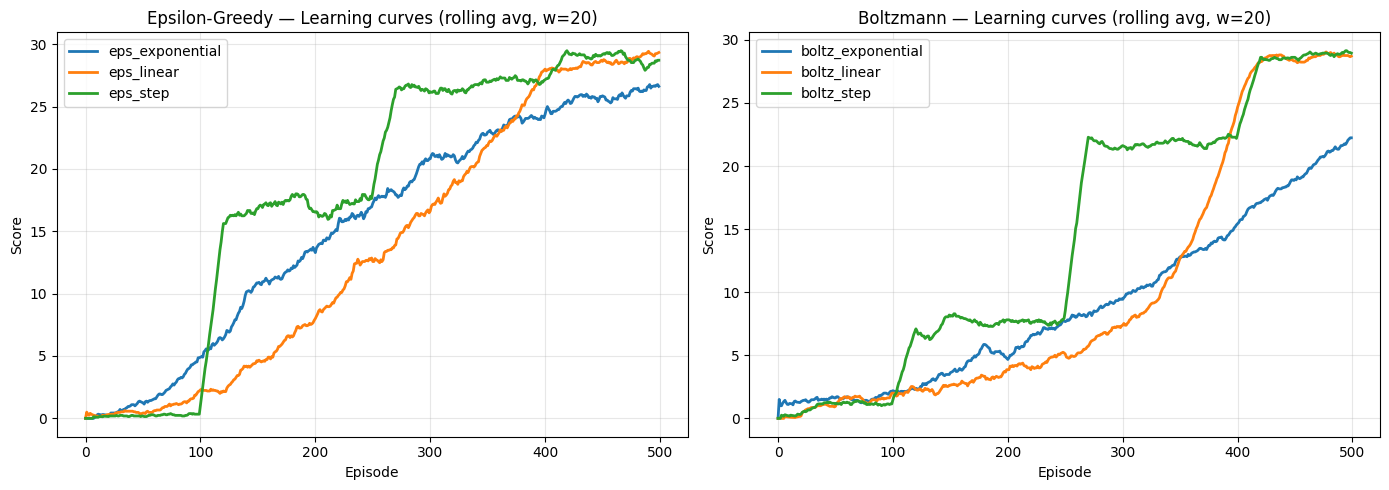

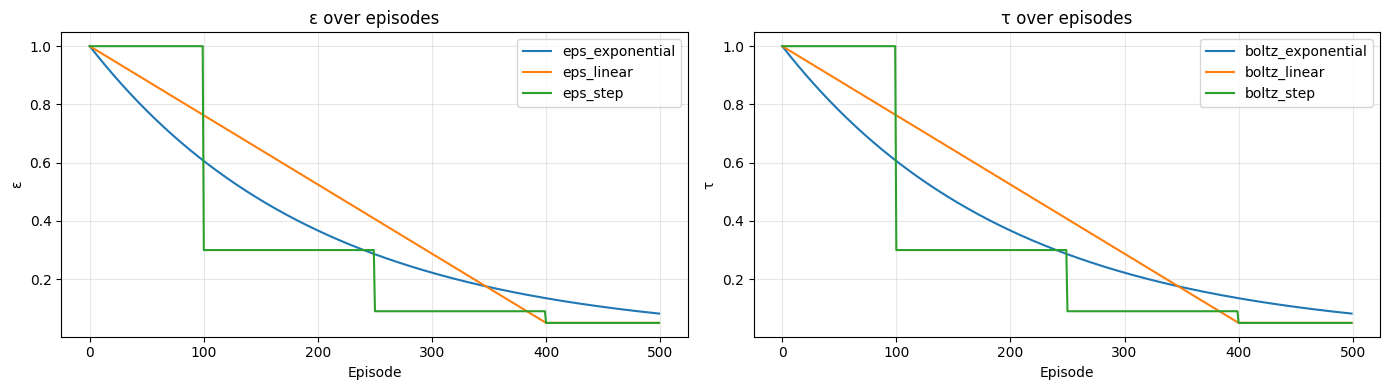

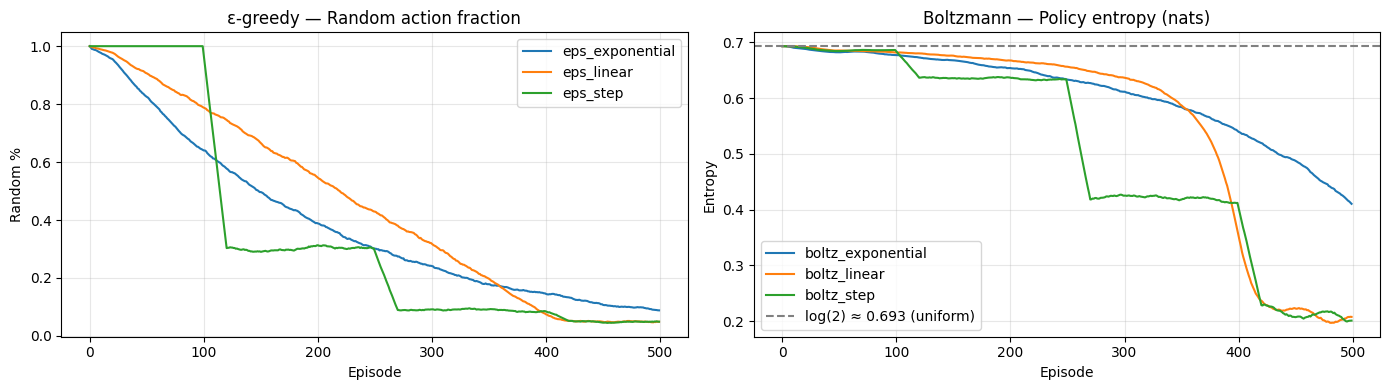

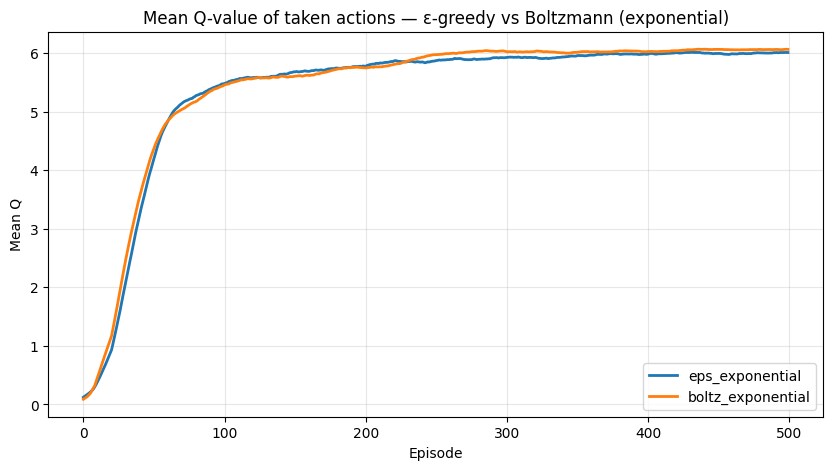

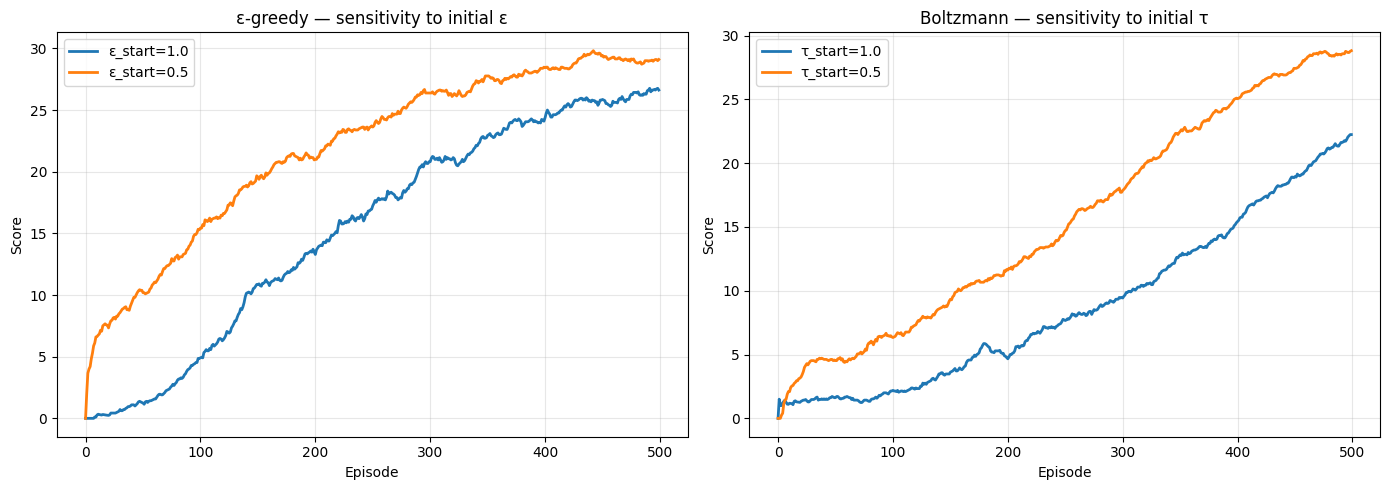

In [ ]:
# Plot A: Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in ["eps_exponential", "eps_linear", "eps_step"]:
    axes[0].plot(rolling_avg(experiments[name]["scores"], 20), label=name, linewidth=2)
axes[0].set_title("Epsilon-Greedy — Learning curves (rolling avg, w=20)")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Score")
axes[0].legend(); axes[0].grid(alpha=0.3)

for name in ["boltz_exponential", "boltz_linear", "boltz_step"]:
    axes[1].plot(rolling_avg(experiments[name]["scores"], 20), label=name, linewidth=2)
axes[1].set_title("Boltzmann — Learning curves (rolling avg, w=20)")
axes[1].set_xlabel("Episode"); axes[1].set_ylabel("Score")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


# Plot B: Schedule trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name in ["eps_exponential", "eps_linear", "eps_step"]:
    axes[0].plot(experiments[name]["param"], label=name)
axes[0].set_title("ε over episodes"); axes[0].set_xlabel("Episode")
axes[0].set_ylabel("ε"); axes[0].legend(); axes[0].grid(alpha=0.3)

for name in ["boltz_exponential", "boltz_linear", "boltz_step"]:
    axes[1].plot(experiments[name]["param"], label=name)
axes[1].set_title("τ over episodes"); axes[1].set_xlabel("Episode")
axes[1].set_ylabel("τ"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


# Plot C: Exploration behavior
# ε-greedy → fraction of random actions per episode
# Boltzmann → policy entropy (nats) per episode
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name in ["eps_exponential", "eps_linear", "eps_step"]:
    axes[0].plot(rolling_avg(experiments[name]["explore"], 20), label=name)
axes[0].set_title("ε-greedy — Random action fraction")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Random %")
axes[0].legend(); axes[0].grid(alpha=0.3)

for name in ["boltz_exponential", "boltz_linear", "boltz_step"]:
    axes[1].plot(rolling_avg(experiments[name]["explore"], 20), label=name)
axes[1].set_title("Boltzmann — Policy entropy (nats)")
axes[1].set_xlabel("Episode"); axes[1].set_ylabel("Entropy")
axes[1].axhline(np.log(2), color='gray', linestyle='--',
                label=f'log(2) ≈ {np.log(2):.3f} (uniform)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


# Plot D: Q-value evolution
fig, ax = plt.subplots(figsize=(10, 5))
for name in ["eps_exponential", "boltz_exponential"]:
    ax.plot(rolling_avg(experiments[name]["mean_q"], 20), label=name, linewidth=2)
ax.set_title("Mean Q-value of taken actions — ε-greedy vs Boltzmann (exponential)")
ax.set_xlabel("Episode"); ax.set_ylabel("Mean Q")
ax.legend(); ax.grid(alpha=0.3); plt.show()


# Plot E: Hyperparameter sensitivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rolling_avg(experiments["eps_exponential"]["scores"], 20),
             label="ε_start=1.0", linewidth=2)
axes[0].plot(rolling_avg(experiments["eps_exp_low_start"]["scores"], 20),
             label="ε_start=0.5", linewidth=2)
axes[0].set_title("ε-greedy — sensitivity to initial ε")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Score")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rolling_avg(experiments["boltz_exponential"]["scores"], 20),
             label="τ_start=1.0", linewidth=2)
axes[1].plot(rolling_avg(experiments["boltz_exp_low_start"]["scores"], 20),
             label="τ_start=0.5", linewidth=2)
axes[1].set_title("Boltzmann — sensitivity to initial τ")
axes[1].set_xlabel("Episode"); axes[1].set_ylabel("Score")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Comments:**

* **Plot A - Learning curves:** All schedules eventually converge to \~28-29 except `boltz_exponential` (\~22) and `eps_exponential` (~27), the two slowest-decaying schedules. Step decay (green) shows the characteristic flat-then-jump shape: the agent is stuck at score 0 while ε/τ = 1.0 (fully random), then leaps the instant the first milestone fires (ep 100). Linear (orange) is the slowest off the line in both panels but catches up by ep 400. Confirms the table: ε learns earlier than Boltzmann at matched schedules.

* **Plot B - ε / τ schedules:** Sanity check of the decay functions, not a result. Exponential (blue) drops fast early then has a long flat tail; linear (orange) is a straight line to ep 400 then constant; step (green) holds flat and drops at the milestones (100, 250, 400). The shapes are identical for ε and τ because the schedule functions are the same - only the action-selection mechanism differs.

* **Plot C - Exploration behavior:** The core mechanistic difference. Left: ε-greedy's random-action fraction tracks ε almost exactly (as it must - exploration % *is* ε). Right: Boltzmann's entropy starts at log(2) ≈ 0.693 (uniform over 2 actions) and stays high - even at τ = 0.3 the policy is still near-uniform, only collapsing toward greedy late in training. This is the visual proof of why Boltzmann explores longer: high temperature on 2 actions barely concentrates the distribution, so it keeps acting near-randomly well after ε-greedy has started exploiting.

* **Plot D - Mean Q-value (ε vs Boltzmann, exponential):** The two curves are essentially identical - both rise steeply over the first ~80 episodes and plateau at ~6.0. Despite very different exploration behavior and final scores, both strategies learn value functions of the same magnitude. Confirms the table's consistent MeanQ column: the strategy choice affects *policy quality and learning speed*, not the scale of the learned values.

* **Plot E - Hyperparameter sensitivity:** Lowering the initial value 1.0 → 0.5 (orange) lifts the whole curve above the 1.0 baseline (blue) for both strategies, especially early. For ε-greedy the gain is large and persists to the final score; for Boltzmann the curve shifts up too, but note that even τ_start = 1.0 wastes many episodes near-random (the blue Boltzmann curve barely moves before ~ep 150). Both strategies benefit from less initial exploration in this 2-action task - there simply isn't enough to explore to justify starting fully random.

* **Takeaway across plots:** ε-greedy and Boltzmann reach the same value function (D) and similar final scores (A), but differ in *how* they explore (C) and *how fast* they get there (A, E). With 2 actions, high-temperature Boltzmann is aproximatelly random for too long, so ε-greedy - and a lower initial exploration value - is the more efficient choice.

In [ ]:
# CURRICULUM TRAINING FOR DIFFICULTY-3 SUBMISSION
# Same loop as train_dqn_exploration, but accepts a pretrained model to continue from (warm-start).
# Refine a difficulty-1 model through difficulty 2 and 3 instead of training from scratch.

def train_dqn_exploration_ws(
    strategy, schedule_fn,
    difficulty=3,
    n_episodes=600,
    gamma=0.99, lr=1e-4, batch_size=32,
    buffer_capacity=10_000, train_freq=1, tau=0.005,
    warmup_steps=1_000,
    pretrained_state=None,
    label="run",
):
    env = SpaceRaceEnv(obs_mode="rgb", difficulty=difficulty)

    primary_net = DQN(n_actions=2).to(device)
    if pretrained_state is not None:
        primary_net.load_state_dict(pretrained_state)
        print(f"[{label}] warm-started from pretrained model")

    target_net = DQN(n_actions=2).to(device)
    target_net.load_state_dict(primary_net.state_dict())
    target_net.eval()
    for p in target_net.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(primary_net.parameters(), lr=lr)
    buffer    = ReplayBuffer(capacity=buffer_capacity)

    obs, info = env.reset()
    for _ in range(warmup_steps):
        action = env.action_space.sample()
        next_obs, reward, term, trunc, next_info = env.step(action)
        done = term or trunc
        buffer.add(obs, action, reward, next_obs, float(done))
        if done:
            obs, info = env.reset()
        else:
            obs, info = next_obs, next_info

    episode_scores, episode_losses, episode_mean_q = [], [], []
    episode_param, episode_explore = [], []
    total_steps = 0
    start_time  = time.time()

    for episode in range(n_episodes):
        param_value = schedule_fn(episode)
        obs, info = env.reset()
        done = False
        ep_loss = ep_q = ep_explore_signal = 0.0
        ep_updates = ep_steps = 0

        while not done:
            if strategy == "epsilon":
                action, was_random = select_action_epsilon_greedy(primary_net, obs, param_value)
                ep_explore_signal += float(was_random)
            else:
                action, entropy = select_action_boltzmann(primary_net, obs, param_value)
                ep_explore_signal += entropy

            next_obs, reward, term, trunc, next_info = env.step(action)
            done = term or trunc
            buffer.add(obs, action, reward, next_obs, float(done))

            with torch.no_grad():
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                ep_q += primary_net(obs_t)[0, action].item()

            obs  = next_obs
            info = next_info
            total_steps += 1
            ep_steps    += 1

            if buffer.is_ready(batch_size) and (total_steps % train_freq == 0):
                batch = buffer.sample(batch_size)
                loss, _, _ = compute_loss_dqn(primary_net, target_net, batch, gamma)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(primary_net.parameters(), max_norm=1.0)
                optimizer.step()
                ep_loss += loss.item()
                ep_updates += 1
                soft_update(primary_net, target_net, tau=tau)

        episode_scores.append(info['score'])
        episode_losses.append(ep_loss / ep_updates if ep_updates > 0 else 0.0)
        episode_mean_q.append(ep_q / ep_steps if ep_steps > 0 else 0.0)
        episode_param.append(param_value)
        episode_explore.append(ep_explore_signal / ep_steps if ep_steps > 0 else 0.0)

        if (episode + 1) % 25 == 0:
            elapsed = (time.time() - start_time) / 60
            print(f"[{label}] Ep {episode+1:4d} | "
                  f"Score: {np.mean(episode_scores[-25:]):6.2f} | "
                  f"Loss: {np.mean(episode_losses[-25:]):.4f} | "
                  f"Q: {np.mean(episode_mean_q[-25:]):6.3f} | "
                  f"{'ε' if strategy=='epsilon' else 'τ'}: {param_value:.3f} | "
                  f"Time: {elapsed:.1f}min")

    return {
        "label": label, "strategy": strategy,
        "scores": episode_scores, "losses": episode_losses,
        "mean_q": episode_mean_q, "param": episode_param,
        "explore": episode_explore,
        "time_min": (time.time() - start_time) / 60,
        "model_state": primary_net.state_dict(),
    }

In [ ]:
import os
SAVE_DIR = "/content/drive/MyDrive/task3"
os.makedirs(SAVE_DIR, exist_ok=True)

# Ponto de partida: melhor modelo de difficulty 1
start = torch.load(os.path.join(SAVE_DIR, "model_task3_eps_exp_low_start.pt"))

# Etapa 1 → difficulty 2
stage2 = train_dqn_exploration_ws(
    "epsilon", lambda ep: epsilon_exponential(ep, 0.4, 0.05, 0.99),
    difficulty=2, n_episodes=300, pretrained_state=start, label="curr_d2")
torch.save(stage2["model_state"], os.path.join(SAVE_DIR, "model_curr_d2.pt"))
print("Etapa difficulty 2 guardada.")

# Etapa 2 → difficulty 3
stage3 = train_dqn_exploration_ws(
    "epsilon", lambda ep: epsilon_exponential(ep, 0.3, 0.05, 0.99),
    difficulty=3, n_episodes=500, pretrained_state=stage2["model_state"], label="curr_d3")
torch.save(stage3["model_state"], os.path.join(SAVE_DIR, "model_curr_d3.pt"))
print("Modelo final: model_curr_d3.pt")

[curr_d2] warm-started from pretrained model
[curr_d2] Ep   25 | Score:   5.68 | Loss: 0.0597 | Q:  3.998 | ε: 0.314 | Time: 1.7min
[curr_d2] Ep   50 | Score:   9.08 | Loss: 0.0377 | Q:  4.544 | ε: 0.244 | Time: 3.3min
[curr_d2] Ep   75 | Score:  11.88 | Loss: 0.0422 | Q:  4.986 | ε: 0.190 | Time: 4.9min
[curr_d2] Ep  100 | Score:  14.88 | Loss: 0.0484 | Q:  5.273 | ε: 0.148 | Time: 6.6min
[curr_d2] Ep  125 | Score:  17.48 | Loss: 0.0510 | Q:  5.514 | ε: 0.115 | Time: 8.2min
[curr_d2] Ep  150 | Score:  19.72 | Loss: 0.0578 | Q:  5.732 | ε: 0.089 | Time: 9.8min
[curr_d2] Ep  175 | Score:  20.92 | Loss: 0.0621 | Q:  5.846 | ε: 0.070 | Time: 11.5min
[curr_d2] Ep  200 | Score:  22.28 | Loss: 0.0567 | Q:  5.950 | ε: 0.054 | Time: 13.1min
[curr_d2] Ep  225 | Score:  23.68 | Loss: 0.0631 | Q:  6.031 | ε: 0.050 | Time: 14.8min
[curr_d2] Ep  250 | Score:  23.88 | Loss: 0.0609 | Q:  6.119 | ε: 0.050 | Time: 16.4min
[curr_d2] Ep  275 | Score:  23.88 | Loss: 0.0647 | Q:  6.149 | ε: 0.050 | Time: 1

In [ ]:
import shutil
shutil.copy(os.path.join(SAVE_DIR, "model_curr_d3.pt"), "model_best.pt")
!python local_eval.py --difficulty 3

  Episode  1/10  →  score = 28
  Episode  2/10  →  score = 29
  Episode  3/10  →  score = 25
  Episode  4/10  →  score = 25
  Episode  5/10  →  score = 26
  Episode  6/10  →  score = 25
  Episode  7/10  →  score = 25
  Episode  8/10  →  score = 25
  Episode  9/10  →  score = 24
  Episode 10/10  →  score = 26

--- Results (difficulty=3) ---
  Mean : 25.80
  Std  : 1.47
  Min  : 24
  Max  : 29



In [ ]:
agent_code = '''
from __future__ import annotations
import numpy as np
import torch
import torch.nn as nn
import os

class DQN(nn.Module):
    def __init__(self, n_actions=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 13 * 9, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = x / 255.0
        x = self.conv(x)
        x = x.flatten(start_dim=1)
        return self.fc(x)

class Agent:
    def __init__(self) -> None:
        self.model = DQN(n_actions=2)
        model_path = os.path.join(os.path.dirname(__file__), "model_best.pt")
        self.model.load_state_dict(torch.load(model_path, map_location="cpu"))
        self.model.eval()

    def select_action(self, obs: np.ndarray) -> int:
        with torch.no_grad():
            obs_t = torch.FloatTensor(obs).unsqueeze(0)
            q_values = self.model(obs_t)
            return int(q_values.argmax(dim=1).item())

'''

with open("agent.py", "w") as f:
    f.write(agent_code)
print("agent.py written (Task 3 — loads model_best.pt)")

agent.py written (Task 3 — loads model_best.pt)


**Isto aqui foi a testar os modelos quando estavam apenas treinados com dificuldade 1**

In [ ]:
import shutil, os

SAVE_DIR = "/content/drive/MyDrive/task3"

eval_results = {}
for name in experiments.keys():
    print(f"\n========== Evaluating {name} ==========")
    src = os.path.join(SAVE_DIR, f"model_task3_{name}.pt")
    shutil.copy(src, "model_best.pt")
    !python local_eval.py --difficulty 3


========== Evaluating eps_exponential ==========
  Episode  1/10  →  score = 13
  Episode  2/10  →  score = 6
  Episode  3/10  →  score = 10
  Episode  4/10  →  score = 9
  Episode  5/10  →  score = 10
  Episode  6/10  →  score = 10
  Episode  7/10  →  score = 10
  Episode  8/10  →  score = 10
  Episode  9/10  →  score = 12
  Episode 10/10  →  score = 12

--- Results (difficulty=3) ---
  Mean : 10.20
  Std  : 1.83
  Min  : 6
  Max  : 13


========== Evaluating eps_linear ==========
  Episode  1/10  →  score = 9
  Episode  2/10  →  score = 8
  Episode  3/10  →  score = 11
  Episode  4/10  →  score = 8
  Episode  5/10  →  score = 10
  Episode  6/10  →  score = 10
  Episode  7/10  →  score = 10
  Episode  8/10  →  score = 12
  Episode  9/10  →  score = 10
  Episode 10/10  →  score = 10

--- Results (difficulty=3) ---
  Mean : 9.80
  Std  : 1.17
  Min  : 8
  Max  : 12


========== Evaluating eps_step ==========
  Episode  1/10  →  score = 13
  Episode  2/10  →  score = 8
  Episode  3/10  

The curriculum used for the difficulty-3 submission applies **ε-greedy with an exponential schedule**, and this is a direct consequence of the comparative analysis above rather than an arbitrary choice. Three findings from Task 3.3 drove this decision:

- **ε-greedy learned faster.** It reached the target score in roughly half the episodes that Boltzmann needed at matched schedules (e.g. exponential: 217 vs 397).
- **ε-greedy is cheaper per step.** Argmax + coin flip vs softmax + multinomial sampling - meaningful in a curriculum where many sequential refinement stages compound the cost.
- **ε-greedy responds predictably to its hyperparameter.** The lower-ε run (`eps_exp_low_start`) was the single best configuration in the table, which is why it was promoted to the warm-start of the curriculum.

Boltzmann's structural advantage: Q-aware exploration that avoids clearly bad actions has no room to pay off in a 2-action environment. The choice therefore reflects what the data actually showed, not a generic preference.

**Training setup vs difficulty-3 score**

The Codabench leaderboard evaluates at difficulty 3, while the comparative analysis above ran at difficulty 1 (where the difference between strategies is cleanest). The table summarises why a curriculum was needed to close the gap, by comparing how the same architecture performs on difficulty 3 under different training setups (`local_eval.py --difficulty 3`, 10 episodes):

| Training setup | Mean score on difficulty 3 |
|---|---|
| Best difficulty-1 model only (no curriculum) | ~11 |
| Curriculum 1 → 2 → 3 (500 + 300 + 500 episodes) | **25** |

* **Row 1 — the generalisation problem.** A model trained only on difficulty 1 performs badly when tested on difficulty 3. It learned to avoid slow and simple obstacles, but those skills do not work well when the obstacles become much faster and more crowded. The model still gives high Q-values (above 6), meaning it is confident, but it is confident in the wrong actions.

* **Row 2 — the benefit of curriculum learning.** Starting with the best difficulty-1 model and then gradually training it on difficulties 2 and 3 improves performance a lot. The agent keeps the basic skills it already learned, such as moving across the screen and dodging obstacles, and only needs to adapt them to harder conditions. This reaches a strong difficulty-3 policy much faster than training directly on difficulty 3, where rewards are too rare early on for learning to begin reliably.

The use of ε-greedy exploration with an exponential decay schedule during the curriculum was based on the comparison in Section S4, which showed that this strategy learned fastest in the simple 2-action setting and also allowed the later training stages to converge quickly.


Este é o melhor modelo após ter feito warmup + treinar com d1, d2 e d3 (500 + 300 + 500 eps)

In [ ]:
import shutil, os
SAVE_DIR = "/content/drive/MyDrive/task3"
shutil.copy(os.path.join(SAVE_DIR, "model_curr_d3.pt"), "model_best.pt")

!zip -j submission_task3.zip agent.py model_best.pt
print("submission_task3.zip criado")

  adding: agent.py (deflated 58%)
  adding: model_best.pt (deflated 7%)
submission_task3.zip criado
